# 🏥 Healthcare Claim Review Assistant


### Pipeline Overview
```
 FLOW:

    START
      ↓
    OCR
      ↓
    Structuring
      ↓
    Validation
      ↓
    Router
      ├── Human Review Queue → END
      ├── Fast Track → END
      └── Parallel Start
              ├── Fraud Agent
              ├── RAG Agent
              └── Duplicate Agent
                        ↓
                    Risk Agent
                        ↓
                  Decision Agent
                        ↓
               Explainability Agent
                        ↓
                       END
```

### Features
- **10 Specialized AI Agents** (Gemini LLM + rule-based fallback)
- **LangGraph Workflow** with conditional routing
- **RAG Pipeline** — ChromaDB + Google Embeddings for policy retrieval
- **Full Audit Trail** for compliance


##Install Dependencies

In [4]:
# !pip install -q langchain langchain-google-genai langgraph langsmith \
#                chromadb==0.4.24 \
#                PyMuPDF pdfplumber pytesseract Pillow pdf2image \
#                pydantic pydantic-settings python-dotenv \
#                loguru tenacity pandas


In [5]:
# pip install numpy==1.26.4

In [6]:
# pip install langchain-text-splitters

In [7]:
# !pip install langchain-community

##Configure API Key


In [35]:
from google.colab import userdata
import os

GOOGLE_API_KEY = userdata.get("GEMINI_API_KEY")

os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

## Configuration

In [9]:
# Configuration
import os
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class Settings:
    # Google Gemini
    google_api_key: str = field(default_factory=lambda: os.getenv("GOOGLE_API_KEY", ""))

    # Model
    gemini_model: str = "gemini-2.5-flash"
    gemini_temperature: float = 0.1
    gemini_max_tokens: int = 4096

    # Embeddings
    embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2"
    embedding_dimension: int = 384

    # ChromaDB
    chroma_persist_directory: str = "/tmp/chroma_db"
    chroma_collection_name: str = "policy_documents"

    # OCR
    ocr_confidence_threshold: float = 0.6

    # Fraud thresholds
    fraud_score_threshold: float = 0.7
    high_risk_amount: float = 100_000.0
    duplicate_similarity_threshold: float = 0.85

    # RAG
    rag_top_k: int = 5
    rag_similarity_threshold: float = 0.7

    # Workflow
    auto_approve_threshold: float = 0.95
    human_review_threshold: float = 0.5

settings = Settings()


##Logging Setup

In [10]:
import logging
from datetime import datetime

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("healthcare_claim")


## State Schema

In [11]:
from typing import TypedDict, List, Dict, Any, Optional, Literal, Annotated
from datetime import datetime
import operator

class ClaimData(TypedDict, total=False):
    claim_id: str
    patient_name: str
    hospital_name: str
    diagnosis: str
    treatment: str
    claim_amount: float
    admission_date: str
    discharge_date: str
    policy_number: str
    policy_tier: str
    additional_info: Dict[str, Any]


class ValidationResult(TypedDict):
    is_valid: bool
    errors: List[str]
    warnings: List[str]
    missing_fields: List[str]
    confidence_score: float


class FraudAnalysis(TypedDict):
    fraud_score: float
    fraud_indicators: List[str]
    risk_level: Literal["LOW", "MEDIUM", "HIGH", "CRITICAL"]
    reasoning: str


class RAGResult(TypedDict):
    retrieved_documents: List[Dict[str, Any]]
    policy_clauses: List[str]
    coverage_analysis: str
    relevance_score: float


class RiskScore(TypedDict):
    risk_score: float
    severity: Literal["LOW", "MEDIUM", "HIGH", "CRITICAL"]
    risk_factors: List[str]
    confidence: float


class DuplicateCheck(TypedDict):
    is_duplicate: bool
    similar_claims: List[Dict[str, Any]]
    similarity_scores: List[float]
    reasoning: str


class DecisionResult(TypedDict):
    decision: Literal["APPROVED", "REJECTED", "ESCALATE"]
    confidence: float
    reasoning: str
    recommended_action: str


class ExplanationResult(TypedDict):
    summary: str
    key_factors: List[str]
    policy_references: List[str]
    human_readable_explanation: str


class WorkflowState(TypedDict, total=False):
    # Input
    claim_pdf_path: str
    claim_text_input: str

    # OCR
    ocr_text: str
    ocr_confidence: float
    ocr_method: str

    # Structuring
    claim_data: ClaimData
    structuring_confidence: float
    structuring_method: str

    # Validation
    validation_result: ValidationResult
    validation_method: str

    # Routing
    route_decision: Literal["human_review", "fast_track", "parallel_pipeline"]
    route_reasoning: str

    # Analysis agents
    fraud_analysis: FraudAnalysis
    rag_result: RAGResult
    risk_score: RiskScore
    duplicate_check: DuplicateCheck

    # Decision
    decision_result: DecisionResult
    decision_method: str

    # Explanation
    explanation: ExplanationResult

    # Final
    final_decision: str
    final_confidence: float

    # Metadata
    workflow_start_time: str
    workflow_end_time: Optional[str]
    errors: List[str]
    warnings: List[str]
    audit_trail: Annotated[
        List[Dict[str, Any]],
        operator.add
    ]


def create_initial_state(claim_pdf_path: str = "") -> WorkflowState:
    return WorkflowState(
        claim_pdf_path=claim_pdf_path,
        workflow_start_time=datetime.now().isoformat(),
        errors=[],
        warnings=[],
        audit_trail=[]
    )


##Validators

In [12]:
import re
from typing import Tuple


def normalize_date(date_str: str) -> Optional[str]:
    """Normalize date string to YYYY-MM-DD."""
    formats = ["%Y-%m-%d", "%d-%m-%Y", "%d/%m/%Y", "%Y/%m/%d", "%d.%m.%Y"]
    for fmt in formats:
        try:
            return datetime.strptime(str(date_str), fmt).strftime("%Y-%m-%d")
        except ValueError:
            continue
    return None


def normalize_amount(amount: Any) -> Optional[float]:
    """Normalize amount string to float."""
    try:
        if isinstance(amount, str):
            amount = amount.replace(",", "").replace("₹", "").replace("$", "").strip()
        return float(amount)
    except (ValueError, TypeError):
        return None


class ClaimValidator:
    REQUIRED_FIELDS = [
        "claim_id", "patient_name", "hospital_name", "diagnosis",
        "treatment", "claim_amount", "admission_date", "discharge_date", "policy_number"
    ]

    RECOMMENDED_FIELDS = [
        "claim_type", "claim_date", "policy_tier", "patient_id", "date_of_birth",
        "age", "gender", "provider_id", "icd_10_code", "cpt_code"
    ]

    OPTIONAL_FIELDS = [
        "provider_specialty", "annual_policy_limit", "co_payment_percentage", "employment_status"
    ]

    @staticmethod
    def validate_claim_id(v: str) -> Tuple[bool, Optional[str]]:
        if not v: return False, "Claim ID missing"
        if not re.match(r'^CLM\d{4,}$', v):
            return False, f"Invalid claim ID format: {v}. Expected CLM####"
        return True, None

    @staticmethod
    def validate_policy_number(v: str) -> Tuple[bool, Optional[str]]:
        if not v: return False, "Policy number missing"
        if not re.match(r'^POL\d{4,}$', v):
            return False, f"Invalid policy number format: {v}. Expected POL####"
        return True, None

    @staticmethod
    def validate_amount(v: Any) -> Tuple[bool, Optional[str]]:
        try:
            f = float(v)
            if f <= 0: return False, f"Amount must be positive: {v}"
            if f > 10_000_000: return False, f"Amount exceeds max limit: {v}"
            return True, None
        except (ValueError, TypeError):
            return False, f"Invalid amount: {v}"

    @staticmethod
    def validate_date(v: str, field: str) -> Tuple[bool, Optional[str]]:
        if not v: return False, f"{field} missing"
        for fmt in ["%Y-%m-%d", "%d-%m-%Y", "%d/%m/%Y", "%Y/%m/%d", "%d.%m.%Y"]:
            try:
                d = datetime.strptime(str(v), fmt)
                if d > datetime.now(): return False, f"{field} cannot be future: {v}"
                if d.year < 1900: return False, f"{field} year too old: {v}"
                return True, None
            except ValueError:
                pass
        return False, f"Unrecognized date format for {field}: {v}"

    @staticmethod
    def validate_claim_type(v: str) -> Tuple[bool, Optional[str]]:
        if not v: return False, "Claim type missing"
        valid_types = ["Dental", "Medical", "Surgery", "Emergency", "Outpatient", "Inpatient"]
        if v not in valid_types:
            return False, f"Invalid claim type: {v}. Expected one of {valid_types}"
        return True, None

    @staticmethod
    def validate_policy_tier(v: str) -> Tuple[bool, Optional[str]]:
        if not v: return False, "Policy tier missing"
        if len(v) < 3:
            return False, f"Policy tier too short: {v}"
        return True, None

    @staticmethod
    def validate_patient_id(v: str) -> Tuple[bool, Optional[str]]:
        if not v: return False, "Patient ID missing"
        if not re.match(r'^[A-Z]{2,4}\d+', v):
            return False, f"Invalid patient ID format: {v}. Expected format: PAT####"
        return True, None

    @staticmethod
    def validate_age(v: Any) -> Tuple[bool, Optional[str]]:
        try:
            age = int(v)
            if age < 0 or age > 150:
                return False, f"Age out of valid range: {age}"
            return True, None
        except (ValueError, TypeError):
            return False, f"Invalid age: {v}"

    @staticmethod
    def validate_gender(v: str) -> Tuple[bool, Optional[str]]:
        if not v: return False, "Gender missing"
        valid_genders = ["Male", "Female", "Other", "M", "F"]
        if v not in valid_genders:
            return False, f"Invalid gender: {v}"
        return True, None

    @staticmethod
    def validate_provider_id(v: str) -> Tuple[bool, Optional[str]]:
        if not v: return False, "Provider ID missing"
        if not re.match(r'^[A-Z]{2,4}\d+', v):
            return False, f"Invalid provider ID format: {v}. Expected format: PRV####"
        return True, None

    @staticmethod
    def validate_icd_10_code(v: str) -> Tuple[bool, Optional[str]]:
        if not v: return False, "ICD-10 code missing"
        if not re.match(r'^[A-Z]\d{2}\.?\d?', v):
            return False, f"Invalid ICD-10 code format: {v}. Expected format: A00.0"
        return True, None

    @staticmethod
    def validate_cpt_code(v: str) -> Tuple[bool, Optional[str]]:
        if not v: return False, "CPT code missing"
        if not re.match(r'^[A-Z]?\d{4,5}$', v):
            return False, f"Invalid CPT code format: {v}. Expected 4-5 digit code"
        return True, None

    @staticmethod
    def validate_co_payment(v: Any) -> Tuple[bool, Optional[str]]:
        try:
            pct = float(v)
            if pct < 0 or pct > 100:
                return False, f"Co-payment percentage out of range: {pct}%"
            return True, None
        except (ValueError, TypeError):
            return False, f"Invalid co-payment percentage: {v}"

    @staticmethod
    def validate_employment_status(v: str) -> Tuple[bool, Optional[str]]:
        if not v: return False, "Employment status missing"
        valid_statuses = ["Employed", "Unemployed", "Self-Employed", "Retired"]
        if v not in valid_statuses:
            return False, f"Invalid employment status: {v}"
        return True, None

    @staticmethod
    def validate_date_range(adm: str, dis: str) -> Tuple[bool, Optional[str]]:
        adm_dt = dis_dt = None
        for fmt in ["%Y-%m-%d", "%d-%m-%Y", "%d/%m/%Y"]:
            try: adm_dt = datetime.strptime(str(adm), fmt); break
            except: pass
        for fmt in ["%Y-%m-%d", "%d-%m-%Y", "%d/%m/%Y"]:
            try: dis_dt = datetime.strptime(str(dis), fmt); break
            except: pass
        if not adm_dt or not dis_dt:
            return False, "Could not parse dates for comparison"
        if dis_dt < adm_dt:
            return False, f"Discharge ({dis}) before admission ({adm})"
        if (dis_dt - adm_dt).days > 365:
            return False, f"Hospital stay > 1 year: {(dis_dt - adm_dt).days} days"
        return True, None

    @classmethod
    def validate_claim_data(cls, claim_data: Dict[str, Any]) -> Dict[str, Any]:
        errors, warnings, missing = [], [], []

        for f in cls.REQUIRED_FIELDS:
            if f not in claim_data or not claim_data[f]:
                missing.append(f)

        missing_recommended = []
        for f in cls.RECOMMENDED_FIELDS:
            if f not in claim_data or not claim_data[f]:
                missing_recommended.append(f)

        validations = [
            ("claim_id", cls.validate_claim_id),
            ("claim_type", cls.validate_claim_type),
            ("policy_number", cls.validate_policy_number),
            ("policy_tier", cls.validate_policy_tier),
            ("patient_id", cls.validate_patient_id),
            ("age", cls.validate_age),
            ("gender", cls.validate_gender),
            ("provider_id", cls.validate_provider_id),
            ("icd_10_code", cls.validate_icd_10_code),
            ("cpt_code", cls.validate_cpt_code),
            ("claim_amount", cls.validate_amount),
            ("annual_policy_limit", cls.validate_amount),
            ("co_payment_percentage", cls.validate_co_payment),
            ("employment_status", cls.validate_employment_status),
        ]

        for key, validator in validations:
            if key in claim_data and claim_data[key]:
                ok, err = validator(claim_data[key])
                if not ok: errors.append(err)

        date_validations = [
            ("admission_date", "Admission date"),
            ("discharge_date", "Discharge date"),
            ("claim_date", "Claim date"),
            ("date_of_birth", "Date of birth")
        ]
        for date_key, label in date_validations:
            if date_key in claim_data and claim_data[date_key]:
                ok, err = cls.validate_date(claim_data[date_key], label)
                if not ok: errors.append(err)

        if "admission_date" in claim_data and "discharge_date" in claim_data:
            if claim_data["admission_date"] and claim_data["discharge_date"]:
                ok, err = cls.validate_date_range(claim_data["admission_date"], claim_data["discharge_date"])
                if not ok: errors.append(err)

        if "date_of_birth" in claim_data and claim_data["date_of_birth"] and "age" in claim_data and claim_data["age"]:
            try:
                for fmt in ["%Y-%m-%d", "%d-%m-%Y", "%d/%m/%Y"]:
                    try:
                        dob = datetime.strptime(str(claim_data["date_of_birth"]), fmt)
                        calculated_age = (datetime.now() - dob).days // 365
                        stated_age = int(claim_data["age"])
                        if abs(calculated_age - stated_age) > 1:
                            warnings.append(f"Age mismatch: stated {stated_age}, calculated {calculated_age} from DOB")
                        break
                    except ValueError:
                        continue
            except: pass

        try:
            claim_amt = float(claim_data.get("claim_amount", 0))
            if claim_amt > 500_000:
                warnings.append(f"High claim amount: {claim_amt}")

            if "annual_policy_limit" in claim_data and claim_data["annual_policy_limit"]:
                limit = float(claim_data["annual_policy_limit"])
                if claim_amt > limit:
                    errors.append(f"Claim amount ({claim_amt}) exceeds annual policy limit ({limit})")
        except: pass

        if "claim_type" in claim_data and claim_data["claim_type"]:
            claim_type = claim_data["claim_type"]
            if claim_type in ["Surgery", "Emergency"] and claim_data.get("claim_amount", 0):
                try:
                    if float(claim_data["claim_amount"]) < 10000:
                        warnings.append(f"{claim_type} claim with unusually low amount")
                except: pass

        if missing_recommended:
            warnings.append(f"Missing recommended fields: {', '.join(missing_recommended[:3])}{'...' if len(missing_recommended) > 3 else ''}")

        base = 1.0 - len(errors)*0.15 - len(warnings)*0.03 - len(missing)*0.08 - len(missing_recommended)*0.02
        return {
            "is_valid": len(errors) == 0 and len(missing) == 0,
            "errors": errors,
            "warnings": warnings,
            "missing_fields": missing,
            "missing_recommended": missing_recommended,
            "confidence_score": max(0.0, min(1.0, base))
        }

print("ClaimValidator ready")


ClaimValidator ready


##Base Agent

In [13]:
from abc import ABC, abstractmethod
from langchain_google_genai import ChatGoogleGenerativeAI
import re


class BaseAgent(ABC):
    """
    Abstract base class for all agents.
    Each agent has:
      - process_with_llm()  — Gemini-powered processing
      - process_with_fallback() — deterministic rule-based fallback
      - process() — tries LLM first, falls back on any exception
    """

    def __init__(self, agent_name: str):
        self.agent_name = agent_name
        self.llm = ChatGoogleGenerativeAI(
            model=settings.gemini_model,
            temperature=settings.gemini_temperature,
            max_output_tokens=settings.gemini_max_tokens,
            google_api_key=settings.google_api_key,
        )
        logger.info(f"Initialized {self.agent_name}")

    @abstractmethod
    def process_with_llm(self, state: WorkflowState) -> WorkflowState: ...

    @abstractmethod
    def process_with_fallback(self, state: WorkflowState) -> WorkflowState: ...

    def process(self, state: WorkflowState) -> WorkflowState:
        logger.info(f"{self.agent_name}: start")
        try:
            result = self.process_with_llm(state)
            logger.info(f"{self.agent_name}: LLM OK")
            return result
        except Exception as e:
            logger.warning(f"{self.agent_name}: LLM failed ({e}). Trying fallback…")
            try:
                result = self.process_with_fallback(state)
                logger.info(f"{self.agent_name}: fallback OK")
                return result
            except Exception as fe:
                logger.error(f"{self.agent_name}: fallback also failed: {fe}")
                state.setdefault("errors", []).append(f"{self.agent_name}: both LLM and fallback failed")
                return state

    def invoke_llm(self, prompt: str) -> str:
      """
      Safely invoke Gemini and normalize output.
      """

      response = self.llm.invoke(prompt)
      content = response.content

      if isinstance(content, list):

          text_parts = []

          for block in content:

              # Dict block
              if isinstance(block, dict):

                  if block.get("type") == "text" and "text" in block:
                      text_parts.append(block["text"])

              # Object block
              elif hasattr(block, "text"):

                  text_parts.append(block.text)

          content = "\n".join(text_parts)

      # Ensure string
      content = str(content).strip()

      # REMOVE markdown code fences
      # ```json ... ```
      content = re.sub(r"^```json\s*", "", content, flags=re.IGNORECASE)
      content = re.sub(r"^```", "", content)
      content = re.sub(r"```$", "", content)

      content = content.strip()

      return content

    def add_audit_entry(self, state: WorkflowState, action: str, details: Dict[str, Any]) -> WorkflowState:
        state.setdefault("audit_trail", []).append({
            "timestamp": datetime.now().isoformat(),
            "agent": self.agent_name,
            "action": action,
            "details": details,
        })
        return state

print("BaseAgent defined")

BaseAgent defined


##OCR Agent

In [14]:
import re, json, io


# OCR Agent
class OCRAgent(BaseAgent):
    """Extracts text from a claim PDF (PyMuPDF → pdfplumber → Tesseract cascade)."""

    def __init__(self):
        super().__init__("OCRAgent")

    def process_with_llm(self, state: WorkflowState) -> WorkflowState:
        # If caller already provided raw text, skip OCR
        if state.get("claim_text_input"):
            state["ocr_text"] = state["claim_text_input"]
            state["ocr_confidence"] = 1.0
            state["ocr_method"] = "manual_input"
            self.add_audit_entry(state, "ocr_extraction",
                {"method": "manual_input", "text_length": len(state["ocr_text"])})
            return state

        pdf_path = state.get("claim_pdf_path")
        if not pdf_path:
            raise ValueError("Neither claim_pdf_path nor claim_text_input provided")

        raw_text = self._extract_pdf_text(pdf_path)

        # LLM cleanup pass
        prompt = f"""You are an expert at cleaning OCR-extracted text from healthcare insurance claim documents.
Clean the following text, fix OCR errors, and preserve all important information:

{raw_text[:3000]}

Return only the cleaned text."""
        enhanced = self.invoke_llm(prompt)

        # Calculate dynamic confidence based on extraction quality
        text_length = len(enhanced.strip())
        has_keywords = any(kw in enhanced.lower() for kw in
                          ['claim', 'patient', 'hospital', 'diagnosis', 'treatment'])
        has_structure = '\n' in enhanced or ':' in enhanced

        # Base confidence on text quality indicators
        confidence = 0.75  # Base confidence for LLM-cleaned text
        if text_length > 200: confidence += 0.05
        if text_length > 500: confidence += 0.05
        if has_keywords: confidence += 0.05
        if has_structure: confidence += 0.05

        state["ocr_text"] = enhanced
        state["ocr_confidence"] = min(round(confidence, 3), 0.95)  # Cap at 0.95
        state["ocr_method"] = "llm"
        self.add_audit_entry(state, "ocr_extraction",
            {"method": "llm", "text_length": text_length,
             "has_keywords": has_keywords, "has_structure": has_structure})
        return state

    def process_with_fallback(self, state: WorkflowState) -> WorkflowState:
        if state.get("claim_text_input"):
            state["ocr_text"] = state["claim_text_input"]
            state["ocr_confidence"] = 1.0
            state["ocr_method"] = "manual_input"
            return state

        pdf_path = state.get("claim_pdf_path", "")
        raw_text = self._extract_pdf_text(pdf_path)

        # Calculate dynamic confidence for fallback
        text_length = len(raw_text.strip())
        has_keywords = any(kw in raw_text.lower() for kw in
                          ['claim', 'patient', 'hospital'])
        has_structure = '\n' in raw_text or ':' in raw_text

        confidence = 0.6  # Lower base for fallback
        if text_length > 200: confidence += 0.05
        if text_length > 500: confidence += 0.05
        if has_keywords: confidence += 0.05
        if has_structure: confidence += 0.05

        state["ocr_text"] = raw_text
        state["ocr_confidence"] = min(round(confidence, 3), 0.80)  # Cap at 0.80 for fallback
        state["ocr_method"] = "fallback"
        self.add_audit_entry(state, "ocr_extraction",
            {"method": "fallback", "text_length": text_length,
             "has_keywords": has_keywords, "has_structure": has_structure})
        return state

    @staticmethod
    def _extract_pdf_text(pdf_path: str) -> str:
        """Try PyMuPDF → pdfplumber → raise."""
        import os
        if not os.path.exists(pdf_path):
            raise FileNotFoundError(f"PDF not found: {pdf_path}")
        try:
            import fitz
            doc = fitz.open(pdf_path)
            text = "\n".join(page.get_text() for page in doc)
            doc.close()
            if text.strip():
                return text
        except Exception as e:
            logger.warning(f"PyMuPDF failed: {e}")
        try:
            import pdfplumber
            with pdfplumber.open(pdf_path) as pdf:
                return "\n".join(p.extract_text() or "" for p in pdf.pages)
        except Exception as e:
            logger.warning(f"pdfplumber failed: {e}")
        raise RuntimeError("All OCR methods failed")

print("OCRAgent defined")

OCRAgent defined


## StructuringAgent

In [15]:
# Structuring Agent
class StructuringAgent(BaseAgent):
    """Converts raw OCR text → structured ClaimData dict using Gemini LLM (regex fallback)."""

    def __init__(self):
        super().__init__("StructuringAgent")

    def process_with_llm(self, state: WorkflowState) -> WorkflowState:
        ocr_text = state.get("ocr_text", "")
        if not ocr_text:
            raise ValueError("ocr_text not found in state")

        prompt = f"""You are an expert at extracting structured information from healthcare insurance claim documents.
Extract ALL the following fields from the claim text. Return ONLY a valid JSON object with ALL 23 fields:

{{
    "claim_id": "CLM#### format (e.g., CLM1002)",
    "claim_type": "Type of claim (e.g., Dental, Medical, Surgery, Emergency)",
    "claim_date": "YYYY-MM-DD format - date claim was submitted",
    "policy_number": "POL#### format (e.g., POL41187)",
    "policy_tier": "Policy tier code (e.g., IND-SIL, IND-GLD)",
    "patient_name": "Full patient name ONLY",
    "patient_id": "Patient ID (e.g., PAT5002)",
    "date_of_birth": "YYYY-MM-DD format",
    "age": "Patient age as number",
    "gender": "Male/Female/Other",
    "hospital_name": "Hospital/clinic name",
    "provider_id": "Provider ID (e.g., PRV1102)",
    "provider_specialty": "Provider specialty (e.g., Dental Surgery, Cardiology)",
    "diagnosis": "Medical diagnosis",
    "icd_10_code": "ICD-10 diagnosis code (e.g., S02.5)",
    "treatment": "Treatment/procedure received",
    "cpt_code": "CPT procedure code (e.g., D7140)",
    "admission_date": "YYYY-MM-DD format",
    "discharge_date": "YYYY-MM-DD format",
    "claim_amount": "Numeric amount only (no currency symbols)",
    "annual_policy_limit": "Numeric amount only",
    "co_payment_percentage": "Co-payment percentage as number (e.g., 10)",
    "employment_status": "Employed/Unemployed/Self-Employed/Retired"
}}

CRITICAL RULES:
- Extract ONLY values, NOT labels (e.g., "IND-SIL" not "Policy Tier: IND-SIL")
- Dates must be in YYYY-MM-DD format
- Numeric fields should be numbers only, no currency symbols or commas
- Use "" (empty string) for truly missing fields
- Return ONLY the JSON object, no explanations

Claim Text:
{ocr_text[:5000]}"""

        response = self.invoke_llm(prompt)
        m = re.search(r'\{{.*\}}', response, re.DOTALL)
        raw = json.loads(m.group() if m else response)
        claim_data = self._normalize(raw)

        # Calculate dynamic confidence based on field extraction
        total_fields = 23  # Total expected fields
        extracted_fields = sum(1 for v in claim_data.values() if v)
        base_confidence = 0.85  # Base LLM confidence
        field_completeness = extracted_fields / total_fields
        # Scale confidence based on completeness
        dynamic_confidence = base_confidence * (0.7 + 0.3 * field_completeness)

        state["claim_data"] = claim_data
        state["structuring_confidence"] = round(dynamic_confidence, 3)
        state["structuring_method"] = "llm"
        self.add_audit_entry(state, "data_structuring",
            {"method": "llm", "fields_extracted": extracted_fields,
             "total_fields": total_fields, "completeness": round(field_completeness, 2)})
        return state

    def process_with_fallback(self, state: WorkflowState) -> WorkflowState:
        ocr_text = state.get("ocr_text", "")
        claim_data = self._regex_extract(ocr_text)
        claim_data = self._normalize(claim_data)

        # Calculate dynamic confidence for fallback
        total_fields = 23
        extracted_fields = sum(1 for v in claim_data.values() if v)
        base_confidence = 0.6  # Base fallback confidence
        field_completeness = extracted_fields / total_fields
        dynamic_confidence = base_confidence * (0.7 + 0.3 * field_completeness)

        state["claim_data"] = claim_data
        state["structuring_confidence"] = round(dynamic_confidence, 3)
        state["structuring_method"] = "fallback"
        self.add_audit_entry(state, "data_structuring",
            {"method": "fallback", "fields_extracted": extracted_fields,
             "total_fields": total_fields, "completeness": round(field_completeness, 2)})
        return state

    @staticmethod
    def _regex_extract(text: str) -> Dict[str, Any]:
        d: Dict[str, Any] = {}

        # Claim ID
        m = re.search(r'(?:Claim\s*(?:ID|Number|No\.?)?\s*:?\s*)?(CLM\d+)', text, re.IGNORECASE)
        if m: d["claim_id"] = m.group(1)

        # Claim Type
        m = re.search(r'Claim\s*Type\s*:?\s*(Dental|Medical|Surgery|Emergency|Outpatient|Inpatient)', text, re.IGNORECASE)
        if m: d["claim_type"] = m.group(1).strip()

        # Claim Date
        m = re.search(r'Claim\s*Date\s*:?\s*(\d{1,2}[-/.]\d{1,2}[-/.]\d{2,4})', text, re.IGNORECASE)
        if m: d["claim_date"] = m.group(1)

        # Policy Number
        m = re.search(r'(?:Policy\s*(?:Number|No\.?)?\s*:?\s*)?(POL\d+)', text, re.IGNORECASE)
        if m: d["policy_number"] = m.group(1)

        # Policy Tier
        m = re.search(r'Policy\s*Tier\s*:?\s*([A-Z]{2,}[\-A-Z0-9]+)', text, re.IGNORECASE)
        if not m:
            m = re.search(r'(?:Plan|Tier|Coverage)\s*Type\s*:?\s*([A-Z][A-Za-z\-\+]+)', text, re.IGNORECASE)
        if not m:
            m = re.search(r'(?:Gold|Silver|Bronze|Platinum|Premium|Basic)[\s\-]?(?:Plus|Premium)?', text, re.IGNORECASE)
        if m: d["policy_tier"] = m.group(1).strip() if m.lastindex and m.lastindex >= 1 else m.group(0).strip()

        # Patient Name
        m = re.search(r'Patient\s*Name\s*:?\s*([A-Z][a-z]+(?:\s+[A-Z][a-z]+)+?)(?=\s*(?:Patient\s*ID|\n|Policy|Claim))', text, re.IGNORECASE)
        if m: d["patient_name"] = m.group(1).strip()

        # Patient ID
        m = re.search(r'Patient\s*ID\s*:?\s*([A-Z]{2,4}\d+)', text, re.IGNORECASE)
        if not m:
            m = re.search(r'Patient\s*ID\s*:?\s*(\d+)', text, re.IGNORECASE)
        if not m:
            m = re.search(r'Patient\s*(?:Identification|ID|Number)\s*:?\s*([A-Za-z0-9\-_]+)', text, re.IGNORECASE)
        if m: d["patient_id"] = m.group(1).strip()

        # Date of Birth
        m = re.search(r'(?:Date\s*of\s*Birth|DOB|Birth\s*Date)\s*:?\s*(\d{1,2}[-/.]\d{1,2}[-/.]\d{2,4})', text, re.IGNORECASE)
        if m: d["date_of_birth"] = m.group(1)

        # Age
        m = re.search(r'Age\s*:?\s*(\d{1,3})', text, re.IGNORECASE)
        if m: d["age"] = m.group(1)

        # Gender
        m = re.search(r'Gender\s*:?\s*(Male|Female|M|F|Other)', text, re.IGNORECASE)
        if m: d["gender"] = m.group(1).strip()

        # Hospital Name
        m = re.search(r'Hospital\s*Name\s*:?\s*([A-Za-z][\w\s&]+(?:Hospital|Clinic|Medical|Center|Centre|Dental))',
                       text, re.IGNORECASE)
        if m: d["hospital_name"] = m.group(1).strip()

        # Provider ID
        m = re.search(r'Provider\s*ID\s*:?\s*([A-Z]{2,4}\d+)', text, re.IGNORECASE)
        if m: d["provider_id"] = m.group(1).strip()

        # Provider Specialty - Stop at next field or newline
        m = re.search(r'Provider\s*Specialty\s*:?\s*([A-Za-z][\w\s&]+?)(?=\s*(?:Provider\s*Location|Attending|Doctor|Diagnosis|Treatment|\n\n|$))', text, re.IGNORECASE)
        if m: d["provider_specialty"] = m.group(1).strip()

        # Diagnosis
        m = re.search(r'Diagnosis\s*:?\s*([A-Za-z][a-zA-Z\s,\-–()]+?)(?=\s*(?:ICD|CPT|Treatment|Claim|$))',
                       text, re.IGNORECASE)
        if m: d["diagnosis"] = m.group(1).strip()

        # ICD-10 Code
        m = re.search(r'ICD[-\s]*10\s*Code\s*:?\s*([A-Z]\d{2}\.?\d?)', text, re.IGNORECASE)
        if m: d["icd_10_code"] = m.group(1).strip()

        # Treatment
        m = re.search(r'(?:Treatment|Procedure)\s*:?\s*([A-Za-z][a-zA-Z\s,\-+()]+?)(?=\n|CPT|Admission|Claim|$)',
                       text, re.IGNORECASE)
        if m: d["treatment"] = m.group(1).strip()

        # CPT Code
        m = re.search(r'CPT\s*Code\s*:?\s*([A-Z]?\d{4,5})', text, re.IGNORECASE)
        if m: d["cpt_code"] = m.group(1).strip()

        # Admission Date
        m = re.search(r'Admission\s*Date\s*:?\s*(\d{1,2}[-/.]\d{1,2}[-/.]\d{2,4})', text, re.IGNORECASE)
        if m: d["admission_date"] = m.group(1)

        # Discharge Date
        m = re.search(r'Discharge\s*Date\s*:?\s*(\d{1,2}[-/.]\d{1,2}[-/.]\d{2,4})', text, re.IGNORECASE)
        if m: d["discharge_date"] = m.group(1)

        # Claim Amount
        m = re.search(r'Claim\s*Amount\s*(?:Requested)?\s*:?\s*(?:Rs\.?|₹|INR)?\s*([\d,]+(?:\.\d{1,2})?)',
                       text, re.IGNORECASE)
        if m: d["claim_amount"] = m.group(1).replace(',', '')

        # Annual Policy Limit
        m = re.search(r'Annual\s*Policy\s*Limit\s*:?\s*(?:Rs\.?|₹|INR)?\s*([\d,]+(?:\.\d{1,2})?)',
                       text, re.IGNORECASE)
        if m: d["annual_policy_limit"] = m.group(1).replace(',', '')

        # Co-payment Percentage
        m = re.search(r'Co[-\s]*payment\s*(?:\(%)?\s*:?\s*(\d{1,3})%?', text, re.IGNORECASE)
        if m: d["co_payment_percentage"] = m.group(1)

        # Employment Status
        m = re.search(r'Employment\s*Status\s*:?\s*(Employed|Unemployed|Self[-\s]?Employed|Retired)', text, re.IGNORECASE)
        if m: d["employment_status"] = m.group(1).strip()

        return d

    @staticmethod
    def _normalize(cd: Dict[str, Any]) -> Dict[str, Any]:
        # First pass: Clean all string fields of newlines, tabs, and extra whitespace
        for key, value in cd.items():
            if isinstance(value, str) and value:
                # Remove newlines and tabs
                cleaned = re.sub(r'[\n\t\r]+', ' ', value)
                # Remove extra whitespace
                cleaned = re.sub(r'\s+', ' ', cleaned).strip()
                cd[key] = cleaned

        # Clean up patient_name - remove any "Patient ID" text that got included
        if cd.get("patient_name"):
            name = cd["patient_name"].strip()
            name = re.sub(r'\s*Patient\s*ID.*$', '', name, flags=re.IGNORECASE)
            name = re.sub(r'\s*Patient\s*Id.*$', '', name, flags=re.IGNORECASE)
            name = re.sub(r'\s*Pat\s*$', '', name, flags=re.IGNORECASE)
            cd["patient_name"] = name.strip().title()

        # Clean up provider_id - remove label text and whitespace
        if cd.get("provider_id"):
            provider_id = str(cd["provider_id"]).strip()
            # Remove "Provider ID:" label if included
            provider_id = re.sub(r'^Provider\s*ID\s*:?\s*', '', provider_id, flags=re.IGNORECASE)
            # Remove newlines and tabs
            provider_id = re.sub(r'[\n\t\r]+', ' ', provider_id)
            # Remove extra whitespace
            provider_id = re.sub(r'\s+', ' ', provider_id).strip()
            # Extract only the ID part (e.g., PRV1102)
            match = re.search(r'([A-Z]{2,4}\d+)', provider_id)
            if match:
                cd["provider_id"] = match.group(1)
            else:
                cd["provider_id"] = provider_id

        # Clean up provider_specialty - remove label text and whitespace
        if cd.get("provider_specialty"):
            specialty = str(cd["provider_specialty"]).strip()
            # Remove "Provider Specialty:" label if included
            specialty = re.sub(r'^Provider\s*Specialty\s*:?\s*', '', specialty, flags=re.IGNORECASE)
            # Remove newlines and tabs
            specialty = re.sub(r'[\n\t\r]+', ' ', specialty)
            # Remove extra whitespace
            specialty = re.sub(r'\s+', ' ', specialty).strip()
            cd["provider_specialty"] = specialty

        # Normalize all date fields
        date_fields = ["admission_date", "discharge_date", "claim_date", "date_of_birth"]
        for key in date_fields:
            if cd.get(key):
                nd = normalize_date(cd[key])
                if nd: cd[key] = nd

        # Normalize all amount fields
        amount_fields = ["claim_amount", "annual_policy_limit"]
        for key in amount_fields:
            if cd.get(key):
                na = normalize_amount(cd[key])
                if na: cd[key] = na

        # Normalize numeric fields
        if cd.get("age"):
            try:
                cd["age"] = int(str(cd["age"]).strip())
            except (ValueError, AttributeError):
                pass

        if cd.get("co_payment_percentage"):
            try:
                cd["co_payment_percentage"] = float(str(cd["co_payment_percentage"]).replace("%", "").strip())
            except (ValueError, AttributeError):
                pass

        # Clean up policy_tier
        if cd.get("policy_tier"):
            tier = cd["policy_tier"].strip()
            tier = re.sub(r'^Policy\s*Tier\s*:?\s*', '', tier, flags=re.IGNORECASE)
            cd["policy_tier"] = tier.strip()

        # Standardize gender
        if cd.get("gender"):
            gender = cd["gender"].strip().lower()
            if gender in ["m", "male"]: cd["gender"] = "Male"
            elif gender in ["f", "female"]: cd["gender"] = "Female"
            else: cd["gender"] = cd["gender"].strip().title()

        return cd

print("OCRAgent defined")

OCRAgent defined


## Validation Agent

In [16]:
class ValidationAgent(BaseAgent):
    """Validates claim data: rule-based first, then LLM semantic pass."""

    def __init__(self):
        super().__init__("ValidationAgent")
        self.validator = ClaimValidator()

    def process_with_llm(self, state: WorkflowState) -> WorkflowState:
        claim_data = state.get("claim_data")
        if not claim_data:
            raise ValueError("claim_data not found")

        rule_result = self.validator.validate_claim_data(claim_data)

        prompt = f"""You are an expert healthcare insurance claim validator.
Analyze the claim data for semantic consistency across all 23 fields:

{json.dumps(claim_data, indent=2)}

Rule-based validation found:
- Errors: {rule_result['errors']}
- Warnings: {rule_result['warnings']}
- Missing recommended: {rule_result.get('missing_recommended', [])}

Perform comprehensive semantic validation:

1. **Clinical Consistency**:
   - Does diagnosis match ICD-10 code?
   - Does treatment match CPT code?
   - Is diagnosis appropriate for patient age/gender?
   - Does provider specialty align with diagnosis/treatment?

2. **Financial Validation**:
   - Is claim amount reasonable for the treatment/claim type?
   - Does claim amount respect annual policy limit?
   - Is co-payment percentage applied correctly?
   - Are Surgery/Emergency claims appropriately priced?

3. **Temporal Consistency**:
   - Is claim date after admission/discharge dates?
   - Is patient age consistent with date of birth?
   - Is hospital stay duration appropriate for diagnosis?

4. **Policy & Demographics**:
   - Does policy tier match claim complexity?
   - Is employment status relevant to claim type?
   - Are patient demographics complete and consistent?

5. **Provider Validation**:
   - Is provider specialty appropriate for treatment?
   - Are provider IDs properly formatted?

Return ONLY this JSON:
{{
    "additional_errors": [],
    "additional_warnings": [],
    "semantic_confidence": 0.0
}}"""
        response = self.invoke_llm(prompt)
        m = re.search(r'\{{.*\}}', response, re.DOTALL)
        llm_val = json.loads(m.group() if m else response)

        all_errors   = rule_result["errors"]   + llm_val.get("additional_errors", [])
        all_warnings = rule_result["warnings"] + llm_val.get("additional_warnings", [])
        combined_conf = (rule_result["confidence_score"] + llm_val.get("semantic_confidence", 0.5)) / 2

        vr = ValidationResult(
            is_valid=len(all_errors) == 0 and len(rule_result["missing_fields"]) == 0,
            errors=all_errors, warnings=all_warnings,
            missing_fields=rule_result["missing_fields"],
            confidence_score=combined_conf
        )
        state["validation_result"] = vr
        state["validation_method"] = "llm"
        self.add_audit_entry(state, "validation", {"method": "llm", "is_valid": vr["is_valid"]})
        return state

    def process_with_fallback(self, state: WorkflowState) -> WorkflowState:
        claim_data = state.get("claim_data")
        if not claim_data:
            raise ValueError("claim_data not found")
        vr = self.validator.validate_claim_data(claim_data)
        state["validation_result"] = vr
        state["validation_method"] = "fallback"
        self.add_audit_entry(state, "validation", {"method": "fallback", "is_valid": vr["is_valid"]})
        return state




print("ValidationAgent defined")


ValidationAgent defined


## Router Agent

In [17]:
class RouterAgent(BaseAgent):
    """Decides routing: human_review / fast_track / parallel_pipeline."""

    def __init__(self):
        super().__init__("RouterAgent")

    def process_with_llm(self, state: WorkflowState) -> WorkflowState:
        claim_data = state.get("claim_data", {})
        vr = state.get("validation_result", {})

        prompt = f"""You are an intelligent routing agent for healthcare insurance claims.
Decide the best processing route based on comprehensive risk assessment:

Claim Data (23 fields): {json.dumps(claim_data, indent=2)}

Validation Results:
- Valid: {vr.get('is_valid')}
- Errors: {vr.get('errors')}
- Warnings: {vr.get('warnings')}
- Missing recommended: {vr.get('missing_recommended', [])}
- Confidence: {vr.get('confidence_score',0):.2f}

Risk Assessment Criteria:

1. **HIGH RISK → human_review**:
   - Confidence < 0.5 or critical errors
   - Missing required fields (claim_id, patient_name, hospital_name, etc.)
   - Claim amount > annual_policy_limit
   - Surgery/Emergency claims > 500,000
   - Age/DOB mismatch or invalid demographics
   - Missing ICD-10/CPT codes for medical claims
   - Provider specialty mismatch with treatment

2. **LOW RISK → fast_track**:
   - Confidence > 0.95 and no errors
   - Claim amount < 50,000
   - All recommended fields present
   - Claim type: Dental or Outpatient
   - Valid ICD-10 and CPT codes
   - Complete patient demographics

3. **MEDIUM RISK → parallel_pipeline**:
   - All other cases
   - Missing some recommended fields but has required
   - Moderate claim amounts (50k-500k)
   - Warnings but no critical errors

Return ONLY:
{{"route": "human_review|fast_track|parallel_pipeline", "reasoning": "...", "risk_level": "high|medium|low"}}"""
        response = self.invoke_llm(prompt)
        m = re.search(r'\{{.*\}}', response, re.DOTALL)
        rd = json.loads(m.group() if m else response)
        state["route_decision"] = rd.get("route", "parallel_pipeline")
        state["route_reasoning"] = rd.get("reasoning", "LLM routing")
        self.add_audit_entry(state, "routing", {"method": "llm", "route": state["route_decision"]})
        return state

    def process_with_fallback(self, state: WorkflowState) -> WorkflowState:
        vr = state.get("validation_result", {})
        claim_data = state.get("claim_data", {})
        conf = vr.get("confidence_score", 0.0)
        errors = vr.get("errors", [])
        missing = vr.get("missing_fields", [])
        missing_recommended = vr.get("missing_recommended", [])

        risk_factors = []

        if conf < settings.human_review_threshold:
            risk_factors.append(f"Low confidence ({conf:.2f})")
        if errors:
            risk_factors.append(f"{len(errors)} errors")
        if len(missing) > 2:
            risk_factors.append(f"{len(missing)} missing required fields")

        try:
            amount = float(claim_data.get("claim_amount", 0))
            annual_limit = float(claim_data.get("annual_policy_limit", 0))

            if annual_limit > 0 and amount > annual_limit:
                risk_factors.append("Exceeds policy limit")

            claim_type = claim_data.get("claim_type", "")
            if claim_type in ["Surgery", "Emergency"] and amount > 500000:
                risk_factors.append(f"High-value {claim_type}")

            if not claim_data.get("icd_10_code") and claim_type in ["Medical", "Surgery", "Emergency"]:
                risk_factors.append("Missing ICD-10 for medical claim")

            if not claim_data.get("cpt_code") and claim_type in ["Surgery", "Dental"]:
                risk_factors.append("Missing CPT code")
        except:
            pass

        if risk_factors:
            route = "human_review"
            reasoning = f"Risk factors: {'; '.join(risk_factors)}"
        elif conf > settings.auto_approve_threshold and not errors:
            try:
                amount = float(claim_data.get("claim_amount", 999999))
                claim_type = claim_data.get("claim_type", "")
                has_codes = claim_data.get("icd_10_code") and claim_data.get("cpt_code")

                if amount < 50000 and claim_type in ["Dental", "Outpatient"] and has_codes:
                    route = "fast_track"
                    reasoning = f"Low-risk: {claim_type}, amount {amount}, complete codes"
                elif amount < 50000:
                    route = "fast_track"
                    reasoning = f"High conf ({conf:.2f}), low amount"
                else:
                    route = "parallel_pipeline"
                    reasoning = "High conf but amount needs review"
            except:
                route = "parallel_pipeline"
                reasoning = "Default routing"
        else:
            route = "parallel_pipeline"
            reasoning = f"Standard processing (conf: {conf:.2f}, {len(missing_recommended)} recommended missing)"

        state["route_decision"] = route
        state["route_reasoning"] = reasoning
        state["risk_factors"] = risk_factors
        self.add_audit_entry(state, "routing", {"method": "fallback", "route": route, "risk_factors": risk_factors})
        return state

print("RouterAgent defined")

RouterAgent defined


## 🔍 Step 10 — Fraud, Risk & Duplicate Agents

In [18]:
class FraudAgent(BaseAgent):

    def __init__(self):
        super().__init__("FraudAgent")


    # LLM FRAUD ANALYSIS

    def process_with_llm(self, state: WorkflowState) -> WorkflowState:

        claim_data = state.get("claim_data", {})

        prompt = f"""
You are a healthcare insurance fraud detection analyst.

Analyze claim data across all 23 fields for fraud indicators.

Claim:
{json.dumps(claim_data, indent=2)}

Comprehensive Fraud Checks:

1. Financial Fraud
- Claim amount vs treatment appropriateness
- Near policy-limit claims
- High-value dental/outpatient claims
- Co-payment manipulation

2. Clinical Fraud
- ICD-10 vs diagnosis match
- CPT vs treatment match
- Provider specialty mismatch
- Age/gender mismatch

3. Temporal Fraud
- Backdated claims
- Invalid admission/discharge ranges
- Suspicious hospital stays

4. Identity Fraud
- Fake hospitals
- Invalid provider/patient IDs
- Duplicate claims

5. Policy Fraud
- Tier mismatch
- Frequent high-value claims

Return ONLY valid JSON:

{{
    "fraud_score": 0.0,
    "fraud_indicators": [],
    "risk_level": "LOW",
    "reasoning": "..."
}}

Scoring:
0-0.3 = LOW
0.3-0.6 = MEDIUM
0.6-0.8 = HIGH
0.8-1.0 = CRITICAL
"""

        response = self.invoke_llm(prompt)

        m = re.search(r"\{.*\}", response, re.DOTALL)

        fa = json.loads(m.group() if m else response)

        result = FraudAnalysis(
            fraud_score=fa.get("fraud_score", 0.0),
            fraud_indicators=fa.get("fraud_indicators", []),
            risk_level=fa.get("risk_level", "LOW"),
            reasoning=fa.get("reasoning", "LLM fraud analysis"),
        )

        # Audit entry
        audit_entry = {
            "timestamp": datetime.now().isoformat(),
            "agent": self.agent_name,
            "action": "fraud_detection",
            "details": {
                "method": "llm",
                "fraud_score": result["fraud_score"],
                "risk_level": result["risk_level"],
            },
        }


        # Return ONLY partial updates for parallel execution
        return {
            "fraud_analysis": result,
            "fraud_method": "llm",
            "audit_trail": [audit_entry],
        }


    # FALLBACK RULE-BASED FRAUD ANALYSIS

    def process_with_fallback(self, state: WorkflowState) -> WorkflowState:

        claim_data = state.get("claim_data", {})

        score = 0.0
        indicators = []

        try:

            amount = float(claim_data.get("claim_amount", 0))
            claim_type = claim_data.get("claim_type", "")
            annual_limit = float(
                claim_data.get("annual_policy_limit", 0)
            )

            # High amount checks
            if amount > settings.high_risk_amount:
                score += 0.3
                indicators.append(f"High amount: {amount}")

            if amount > 500_000:
                score += 0.2
                indicators.append(f"Unusually high amount: {amount}")

            # Claim-type specific checks
            if claim_type == "Dental" and amount > 100_000:
                score += 0.25
                indicators.append(
                    f"Suspicious Dental claim: {amount}"
                )

            if claim_type == "Outpatient" and amount > 200_000:
                score += 0.2
                indicators.append(
                    f"High Outpatient claim: {amount}"
                )

            # Near policy limit
            if annual_limit > 0 and amount > annual_limit * 0.95:
                score += 0.15
                indicators.append(
                    f"Near policy limit: {amount}/{annual_limit}"
                )

        except Exception:
            pass


        # DATE VALIDATION


        adm = claim_data.get("admission_date", "")
        dis = claim_data.get("discharge_date", "")
        claim_date = claim_data.get("claim_date", "")

        if adm and dis:

            nd_adm = normalize_date(adm)
            nd_dis = normalize_date(dis)

            if nd_adm and nd_dis:

                d1 = datetime.strptime(nd_adm, "%Y-%m-%d")
                d2 = datetime.strptime(nd_dis, "%Y-%m-%d")

                days = (d2 - d1).days

                if days > 30:
                    score += 0.2
                    indicators.append(f"Long stay: {days}d")

                if days < 0:
                    score += 0.4
                    indicators.append("Invalid admission/discharge dates")

                if claim_date:

                    nd_claim = normalize_date(claim_date)

                    if nd_claim:

                        d_claim = datetime.strptime(
                            nd_claim,
                            "%Y-%m-%d"
                        )

                        if d_claim < d2:
                            score += 0.3
                            indicators.append(
                                "Claim filed before discharge"
                            )


        # AGE VALIDATION


        if (
            claim_data.get("age")
            and claim_data.get("date_of_birth")
        ):

            try:

                dob = normalize_date(
                    claim_data["date_of_birth"]
                )

                if dob:

                    d_dob = datetime.strptime(
                        dob,
                        "%Y-%m-%d"
                    )

                    calc_age = (
                        datetime.now() - d_dob
                    ).days // 365

                    stated_age = int(claim_data["age"])

                    if abs(calc_age - stated_age) > 2:
                        score += 0.2
                        indicators.append(
                            f"Age mismatch: "
                            f"stated {stated_age}, "
                            f"calculated {calc_age}"
                        )

            except Exception:
                pass


        # HOSPITAL VALIDATION


        hosp = claim_data.get(
            "hospital_name",
            ""
        ).lower()

        if any(
            k in hosp
            for k in ["unknown", "test", "dummy", "fake"]
        ):
            score += 0.3
            indicators.append("Suspicious hospital name")

        # Missing ICD
        if (
            not claim_data.get("icd_10_code")
            and claim_data.get("claim_type")
            in ["Medical", "Surgery", "Emergency"]
        ):
            score += 0.15
            indicators.append(
                "Missing ICD-10 code"
            )

        # Missing CPT
        if (
            not claim_data.get("cpt_code")
            and claim_data.get("claim_type")
            in ["Surgery", "Dental"]
        ):
            score += 0.15
            indicators.append(
                "Missing CPT code"
            )

        # PROVIDER SPECIALTY MISMATCH


        provider_specialty = claim_data.get(
            "provider_specialty",
            ""
        ).lower()

        diagnosis = claim_data.get(
            "diagnosis",
            ""
        ).lower()

        if provider_specialty and diagnosis:

            mismatches = [

                (
                    "dental" in provider_specialty
                    and "heart" in diagnosis
                ),

                (
                    "cardiology" in provider_specialty
                    and "dental" in diagnosis
                ),

                (
                    "orthopedic" in provider_specialty
                    and "cardiac" in diagnosis
                ),
            ]

            if any(mismatches):

                score += 0.25

                indicators.append(
                    f"Provider specialty mismatch: "
                    f"{provider_specialty} vs {diagnosis}"
                )


        # FINAL RISK SCORE


        score = min(1.0, score)

        if score < 0.3:
            risk = "LOW"
        elif score < 0.6:
            risk = "MEDIUM"
        elif score < 0.8:
            risk = "HIGH"
        else:
            risk = "CRITICAL"

        result = FraudAnalysis(
            fraud_score=score,
            fraud_indicators=indicators,
            risk_level=risk,
            reasoning=f"Rule-based: {len(indicators)} indicators",
        )

        # Audit entry
        audit_entry = {
            "timestamp": datetime.now().isoformat(),
            "agent": self.agent_name,
            "action": "fraud_detection",
            "details": {
                "method": "fallback",
                "fraud_score": score,
                "risk_level": risk,
            },
        }

        # IMPORTANT:
        # Return ONLY partial updates
        return {
            "fraud_analysis": result,
            "fraud_method": "fallback",
            "audit_trail": [audit_entry],
        }


class RiskAgent(BaseAgent):
    def __init__(self):
        super().__init__("RiskAgent")

    def process_with_llm(self, state: WorkflowState) -> WorkflowState:
        claim_data = state.get("claim_data", {})
        vr = state.get("validation_result", {})
        fa = state.get("fraud_analysis", {})
        prompt = f"""You are a risk assessment analyst for healthcare insurance claims.
Perform comprehensive risk assessment across all 23 fields:

Claim Data: {json.dumps(claim_data, indent=2)}

Validation Results:
- Confidence: {vr.get('confidence_score', 0):.2f}
- Errors: {len(vr.get('errors',[]))}
- Warnings: {len(vr.get('warnings',[]))}
- Missing recommended: {len(vr.get('missing_recommended',[]))}

Fraud Analysis:
- Fraud score: {fa.get('fraud_score', 0):.2f}
- Risk level: {fa.get('risk_level','UNKNOWN')}
- Indicators: {fa.get('fraud_indicators',[])}

Assess overall risk across these dimensions:

1. **Financial Risk**:
   - Claim amount vs annual_policy_limit
   - Claim type appropriateness for amount
   - Co-payment percentage compliance

2. **Clinical Risk**:
   - ICD-10/CPT code validity and matching
   - Provider specialty alignment
   - Age/gender appropriateness for diagnosis

3. **Data Quality Risk**:
   - Missing critical fields (patient_id, provider_id, codes)
   - Date consistency (DOB vs age, claim vs discharge)
   - Field completeness (23 fields)

4. **Fraud Risk**:
   - Fraud score and indicators
   - Pattern anomalies
   - Policy limit exploitation

5. **Operational Risk**:
   - Processing complexity
   - Documentation completeness
   - Verification requirements

Return ONLY:
{{
    "risk_score": 0.0,
    "severity": "LOW|MEDIUM|HIGH|CRITICAL",
    "risk_factors": [],
    "confidence": 0.0
}}"""
        response = self.invoke_llm(prompt)
        m = re.search(r'\{{.*\}}', response, re.DOTALL)
        ra = json.loads(m.group() if m else response)
        result = RiskScore(risk_score=ra.get("risk_score", 0.5),
                           severity=ra.get("severity", "MEDIUM"),
                           risk_factors=ra.get("risk_factors", []),
                           confidence=ra.get("confidence", 0.5))
        state["risk_score"] = result
        state["risk_method"] = "llm"
        self.add_audit_entry(state, "risk_assessment",
            {"method": "llm", "risk_score": result["risk_score"], "severity": result["severity"]})
        return state

    def process_with_fallback(self, state: WorkflowState) -> WorkflowState:
        vr = state.get("validation_result", {})
        fa = state.get("fraud_analysis", {})
        claim_data = state.get("claim_data", {})
        score = 0.0; factors = []

        val_conf = vr.get("confidence_score", 0.5)
        if val_conf < 0.5:
            score += 0.3; factors.append(f"Low validation confidence: {val_conf:.2f}")

        fraud = fa.get("fraud_score", 0.0)
        score += fraud * 0.4
        if fraud > 0.5: factors.append(f"High fraud risk: {fraud:.2f}")

        errs = len(vr.get("errors", []))
        if errs: score += min(0.3, errs * 0.1); factors.append(f"{errs} validation errors")

        missing_recommended = len(vr.get("missing_recommended", []))
        if missing_recommended > 5:
            score += 0.15; factors.append(f"{missing_recommended} recommended fields missing")

        try:
            amount = float(claim_data.get("claim_amount", 0))
            claim_type = claim_data.get("claim_type", "")
            annual_limit = float(claim_data.get("annual_policy_limit", 0))

            if amount > 200_000: score += 0.2; factors.append(f"High amount: {amount}")

            if claim_type in ["Surgery", "Emergency"] and amount > 500_000:
                score += 0.15; factors.append(f"High-value {claim_type}: {amount}")

            if annual_limit > 0 and amount > annual_limit:
                score += 0.25; factors.append(f"Exceeds policy limit: {amount} > {annual_limit}")
        except: pass

        if not claim_data.get("icd_10_code") and claim_data.get("claim_type") in ["Medical", "Surgery", "Emergency"]:
            score += 0.1; factors.append("Missing ICD-10 code")

        if not claim_data.get("cpt_code") and claim_data.get("claim_type") in ["Surgery", "Dental"]:
            score += 0.1; factors.append("Missing CPT code")

        if not claim_data.get("provider_id"):
            score += 0.05; factors.append("Missing provider ID")

        if claim_data.get("age"):
            try:
                age = int(claim_data["age"])
                if age > 80 and claim_data.get("claim_type") == "Surgery":
                    score += 0.1; factors.append(f"High-risk age for surgery: {age}")
            except: pass

        score = min(1.0, score)
        if score < 0.3:   sev, conf = "LOW", 0.8
        elif score < 0.6: sev, conf = "MEDIUM", 0.7
        elif score < 0.8: sev, conf = "HIGH", 0.6
        else:             sev, conf = "CRITICAL", 0.5

        result = RiskScore(risk_score=score, severity=sev, risk_factors=factors, confidence=conf)
        state["risk_score"] = result
        state["risk_method"] = "fallback"
        self.add_audit_entry(state, "risk_assessment",
            {"method": "fallback", "risk_score": score, "severity": sev})
        return state


class DuplicateAgent(BaseAgent):

    def __init__(self):

        super().__init__("DuplicateAgent")

        self.claim_history: List[Dict[str, Any]] = []

    # LLM PATH

    def process_with_llm(
        self,
        state: WorkflowState
    ) -> WorkflowState:

        return self.process_with_fallback(state)

    # FALLBACK DUPLICATE DETECTION

    def process_with_fallback(
        self,
        state: WorkflowState
    ) -> WorkflowState:

        claim_data = state.get("claim_data", {})

        similar = self._find_similar(claim_data)

        is_dup = False

        scores = []

        for sc in similar:

            s = self._similarity(claim_data, sc)

            scores.append(s)

            if s > settings.duplicate_similarity_threshold:

                is_dup = True

                break

        result = DuplicateCheck(

            is_duplicate=is_dup,

            similar_claims=similar,

            similarity_scores=scores,

            reasoning=(
                f"{len(similar)} similar claims; "
                f"max similarity: "
                f"{max(scores) if scores else 0:.2f}"
            )
        )

        # Audit entry
        audit_entry = {

            "timestamp": datetime.now().isoformat(),

            "agent": self.agent_name,

            "action": "duplicate_detection",

            "details": {

                "is_duplicate": is_dup,

                "similar_count": len(similar),

                "max_similarity": (
                    max(scores)
                    if scores else 0.0
                ),
            },
        }

        # IMPORTANT:
        # Return ONLY partial updates
        # for LangGraph parallel execution
        return {

            "duplicate_check": result,

            "duplicate_method": "fallback",

            "audit_trail": [audit_entry],
        }

    # FIND SIMILAR CLAIMS

    def _find_similar(
        self,
        cd: Dict
    ) -> List[Dict]:

        name = cd.get(
            "patient_name",
            ""
        ).lower()

        pol = cd.get(
            "policy_number",
            ""
        )

        patient_id = cd.get(
            "patient_id",
            ""
        )

        dob = cd.get(
            "date_of_birth",
            ""
        )

        candidates = []

        for h in self.claim_history:

            if (

                h.get(
                    "patient_name",
                    ""
                ).lower() == name

                or

                h.get("policy_number") == pol

                or

                h.get("patient_id") == patient_id

                or

                (
                    dob
                    and h.get("date_of_birth") == dob
                )
            ):

                candidates.append(h)

        return candidates[:10]


    # SIMILARITY CALCULATION
    @staticmethod
    def _similarity(
        a: Dict,
        b: Dict
    ) -> float:

        weights = {

            "patient_name": 0.20,

            "policy_number": 0.20,

            "patient_id": 0.15,

            "date_of_birth": 0.10,

            "diagnosis": 0.10,

            "icd_10_code": 0.05,

            "treatment": 0.10,

            "cpt_code": 0.05,

            "hospital_name": 0.05,

            "claim_amount": 0.05,

            "admission_date": 0.03,

            "discharge_date": 0.02,
        }

        sc = 0.0

        for f, w in weights.items():

            v1 = str(
                a.get(f, "")
            ).lower()

            v2 = str(
                b.get(f, "")
            ).lower()

            if v1 and v2:

                # Exact match
                if v1 == v2:

                    sc += w

                # Numeric similarity
                elif f == "claim_amount":

                    try:

                        d = (
                            abs(float(v1) - float(v2))
                            /
                            max(float(v1), float(v2))
                        )

                        if d < 0.1:

                            sc += w * 0.8

                    except Exception:
                        pass

                # Date similarity
                elif f in [
                    "admission_date",
                    "discharge_date"
                ]:

                    nd1 = normalize_date(v1)

                    nd2 = normalize_date(v2)

                    if nd1 and nd2:

                        try:

                            d1 = datetime.strptime(
                                nd1,
                                "%Y-%m-%d"
                            )

                            d2 = datetime.strptime(
                                nd2,
                                "%Y-%m-%d"
                            )

                            days_diff = abs(
                                (d1 - d2).days
                            )

                            if days_diff <= 7:

                                sc += w * 0.9

                            elif days_diff <= 30:

                                sc += w * 0.5

                        except Exception:
                            pass

        return sc

    # ADD CLAIM TO HISTORY

    def add_to_history(
        self,
        claim_data: Dict
    ):

        self.claim_history.append(claim_data)

        # Keep memory bounded
        if len(self.claim_history) > 100:

            self.claim_history = (
                self.claim_history[-100:]
            )


print("FraudAgent, RiskAgent, DuplicateAgent defined")


FraudAgent, RiskAgent, DuplicateAgent defined


##RAG Agent

In [19]:
import chromadb
from langchain_text_splitters import RecursiveCharacterTextSplitter

class PolicyStore:
    """Simple ChromaDB-backed policy document store with optional Google embeddings."""

    def __init__(self):
        self.client = chromadb.PersistentClient(path=settings.chroma_persist_directory)
        try:
            self.col = self.client.get_collection(settings.chroma_collection_name)
        except:
            self.col = self.client.create_collection(settings.chroma_collection_name)
        self.splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)

        # Try to set up Google embeddings; fall back to keyword search
        self._embeddings = None
        try:
          from langchain_community.embeddings import HuggingFaceEmbeddings
          self._embeddings = HuggingFaceEmbeddings(
              model_name=settings.embedding_model
              )
        except Exception as e:
            logger.warning(f"Embeddings unavailable: {e}. Using keyword search.")

    def ingest_text(self, policy_text: str, policy_id: str = "POLICY001"):
        """Ingest plain text policy document."""
        chunks = self.splitter.split_text(policy_text)
        docs, metas, ids = [], [], []
        for i, chunk in enumerate(chunks):
            docs.append(chunk)
            metas.append({"policy_id": policy_id, "chunk": i})
            ids.append(f"{policy_id}_chunk_{i}")

        if self._embeddings:
            embs = self._embeddings.embed_documents(docs)
            self.col.add(documents=docs, embeddings=embs, metadatas=metas, ids=ids)
        else:
            self.col.add(documents=docs, metadatas=metas, ids=ids)
        logger.info(f"Ingested {len(chunks)} chunks for {policy_id}")

    def query(self, query: str, top_k: int = 5) -> List[Dict]:
        if self.col.count() == 0:
            return []
        if self._embeddings:
            try:
                q_emb = self._embeddings.embed_query(query)
                res = self.col.query(query_embeddings=[q_emb], n_results=min(top_k, self.col.count()))
                return [{"content": d, "metadata": m, "distance": dist}
                        for d, m, dist in zip(res["documents"][0], res["metadatas"][0], res["distances"][0])]
            except Exception as e:
                logger.warning(f"Embedding query failed: {e}. Falling back to keyword.")
        # Keyword fallback
        all_docs = self.col.get()
        q_terms = set(query.lower().split())
        scored = []
        for doc, meta in zip(all_docs["documents"], all_docs["metadatas"]):
            s = sum(doc.lower().count(t) for t in q_terms)
            if s > 0: scored.append({"content": doc, "metadata": meta, "distance": 1/(1+s), "score": s})
        scored.sort(key=lambda x: x["score"], reverse=True)
        return scored[:top_k]

    def count(self): return self.col.count()


# Global policy store shared by all agents
policy_store = PolicyStore()
print(f"PolicyStore ready — {policy_store.count()} chunks loaded")


class RAGAgent(BaseAgent):
    """Enhanced RAG agent that uses all 23 claim fields for comprehensive policy matching."""

    def __init__(self, store: PolicyStore):
        super().__init__("RAGAgent")
        self.store = store

    def _build_query(self, claim_data: Dict[str, Any]) -> str:
        """Build comprehensive query from all 23 fields for better policy matching."""
        query_parts = []

        if claim_data.get('claim_type'):
            query_parts.append(f"claim type: {claim_data['claim_type']}")
        if claim_data.get('diagnosis'):
            query_parts.append(f"diagnosis: {claim_data['diagnosis']}")
        if claim_data.get('icd_10_code'):
            query_parts.append(f"ICD-10: {claim_data['icd_10_code']}")
        if claim_data.get('treatment'):
            query_parts.append(f"treatment: {claim_data['treatment']}")
        if claim_data.get('cpt_code'):
            query_parts.append(f"CPT: {claim_data['cpt_code']}")
        if claim_data.get('provider_specialty'):
            query_parts.append(f"specialty: {claim_data['provider_specialty']}")
        if claim_data.get('policy_tier'):
            query_parts.append(f"policy tier: {claim_data['policy_tier']}")
        if claim_data.get('age'):
            query_parts.append(f"patient age: {claim_data['age']}")
        if claim_data.get('employment_status'):
            query_parts.append(f"employment: {claim_data['employment_status']}")

        return " ".join(query_parts) if query_parts else "general coverage"

    def process_with_llm(self, state: WorkflowState) -> WorkflowState:
        claim_data = state.get("claim_data", {})
        query = self._build_query(claim_data)
        docs = self.store.query(query, top_k=settings.rag_top_k)
        clauses = [d["content"] for d in docs[:5]]

        prompt = f"""You are a healthcare insurance policy analyst.
Analyze policy coverage for this claim using all available information:

Claim Details (23 Fields):
- Claim ID: {claim_data.get('claim_id', 'N/A')}
- Claim Type: {claim_data.get('claim_type', 'N/A')}
- Policy Tier: {claim_data.get('policy_tier', 'N/A')}

Patient Information:
- Name: {claim_data.get('patient_name', 'N/A')}
- Age: {claim_data.get('age', 'N/A')}
- Gender: {claim_data.get('gender', 'N/A')}
- Employment: {claim_data.get('employment_status', 'N/A')}

Clinical Information:
- Diagnosis: {claim_data.get('diagnosis', 'N/A')}
- ICD-10 Code: {claim_data.get('icd_10_code', 'N/A')}
- Treatment: {claim_data.get('treatment', 'N/A')}
- CPT Code: {claim_data.get('cpt_code', 'N/A')}
- Provider Specialty: {claim_data.get('provider_specialty', 'N/A')}

Financial Information:
- Claim Amount: {claim_data.get('claim_amount', 'N/A')}
- Annual Policy Limit: {claim_data.get('annual_policy_limit', 'N/A')}
- Co-payment %: {claim_data.get('co_payment_percentage', 'N/A')}

Retrieved Policy Clauses:
{chr(10).join(f'{i+1}. {c[:600]}...' for i,c in enumerate(clauses)) or 'No policy documents available.'}

Comprehensive Analysis Required:

1. **Coverage Determination**:
   - Is this claim type covered under the policy tier?
   - Does the policy cover this specific diagnosis (ICD-10) and treatment (CPT)?
   - Does provider specialty matter for coverage?

2. **Exclusions & Limitations**:
   - Age-based exclusions?
   - Employment status restrictions?
   - Treatment-specific exclusions?

3. **Financial Coverage**:
   - Coverage percentage for this claim type?
   - Does claim amount exceed policy limits?
   - Co-payment requirements?

Return ONLY valid JSON:
{{
    "coverage_analysis": "Detailed analysis...",
    "is_covered": true,
    "coverage_percentage": 80,
    "exclusions_apply": [],
    "estimated_payout": 0.0,
    "patient_responsibility": 0.0
}}"""
        response = self.invoke_llm(prompt)
        m = re.search(r'\{.*\}', response, re.DOTALL)
        analysis = json.loads(m.group() if m else response)

        rr = RAGResult(
            retrieved_documents=docs,
            policy_clauses=clauses,
            coverage_analysis=analysis.get("coverage_analysis", ""),
            relevance_score=self._relevance(docs),
            is_covered=analysis.get("is_covered", False),
            coverage_percentage=analysis.get("coverage_percentage", 0),
            exclusions=analysis.get("exclusions_apply", []),
            estimated_payout=analysis.get("estimated_payout", 0.0),
            patient_responsibility=analysis.get("patient_responsibility", 0.0)
        )

        state["rag_result"] = rr
        state["rag_method"] = "llm"
        self.add_audit_entry(state, "rag_retrieval",
            {"method": "llm", "docs_retrieved": len(docs), "is_covered": rr.get("is_covered")})
        return state

    def process_with_fallback(self, state: WorkflowState) -> WorkflowState:
        claim_data = state.get("claim_data", {})
        query = self._build_query(claim_data)
        docs = self.store.query(query, top_k=settings.rag_top_k)
        clauses = [d["content"] for d in docs[:5]]

        diag = claim_data.get("diagnosis", "").lower()
        treat = claim_data.get("treatment", "").lower()
        claim_type = claim_data.get("claim_type", "").lower()
        icd_code = claim_data.get("icd_10_code", "").lower()
        cpt_code = claim_data.get("cpt_code", "").lower()
        policy_tier = claim_data.get("policy_tier", "").lower()

        coverage_indicators = []
        exclusion_indicators = []

        for clause in clauses:
            c_lower = clause.lower()

            if diag and diag in c_lower:
                coverage_indicators.append("diagnosis")
            if treat and treat in c_lower:
                coverage_indicators.append("treatment")
            if icd_code and icd_code in c_lower:
                coverage_indicators.append("ICD-10")
            if cpt_code and cpt_code in c_lower:
                coverage_indicators.append("CPT")
            if claim_type and claim_type in c_lower:
                coverage_indicators.append("claim_type")
            if policy_tier and policy_tier in c_lower:
                coverage_indicators.append("policy_tier")

            if "exclusion" in c_lower or "not covered" in c_lower or "excluded" in c_lower:
                if any(term in c_lower for term in [diag, treat, claim_type, icd_code]):
                    exclusion_indicators.append(clause[:200])

        age = claim_data.get("age")
        if age:
            try:
                age_num = int(age)
                for clause in clauses:
                    if "age" in clause.lower():
                        if any(word in clause.lower() for word in ["over", "above", "65", "senior"]):
                            if age_num >= 65:
                                coverage_indicators.append("age_eligible")
            except: pass

        cov_found = len(coverage_indicators) > 0
        excl_found = len(exclusion_indicators) > 0

        if excl_found:
            cov_text = f"Policy may exclude this claim. Found exclusions for: {', '.join(set(coverage_indicators))}. Manual review required."
            is_covered = False
            coverage_pct = 0
        elif cov_found:
            cov_text = f"Policy appears to cover this claim. Matched on: {', '.join(set(coverage_indicators))}. Verify specific limits and conditions."
            is_covered = True
            coverage_pct = 80
        else:
            cov_text = "Coverage unclear from available policy documents. No specific matches found. Manual review required."
            is_covered = False
            coverage_pct = 0

        try:
            claim_amt = float(claim_data.get("claim_amount", 0))
            if is_covered and coverage_pct > 0:
                estimated_payout = claim_amt * (coverage_pct / 100)
                patient_resp = claim_amt - estimated_payout
            else:
                estimated_payout = 0.0
                patient_resp = claim_amt
        except:
            estimated_payout = 0.0
            patient_resp = 0.0

        rr = RAGResult(
            retrieved_documents=docs,
            policy_clauses=clauses,
            coverage_analysis=cov_text,
            relevance_score=self._relevance(docs),
            is_covered=is_covered,
            coverage_percentage=coverage_pct,
            exclusions=exclusion_indicators,
            estimated_payout=estimated_payout,
            patient_responsibility=patient_resp
        )

        state["rag_result"] = rr
        state["rag_method"] = "fallback"
        self.add_audit_entry(state, "rag_retrieval",
            {"method": "fallback", "docs_retrieved": len(docs), "is_covered": is_covered})
        return state

    @staticmethod
    def _relevance(docs: List[Dict]) -> float:
        """Calculate average relevance score from retrieved documents."""
        if not docs:
            return 0.0
        return max(0.0, 1.0 - sum(d.get("distance", 1) for d in docs) / len(docs))

print("RAGAgent defined")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
/tmp/ipykernel_2181/3439790276.py:18: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings
/tmp/ipykernel_2181/3439790276.py:19: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_hug

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

PolicyStore ready — 0 chunks loaded
RAGAgent defined


Add Folder Ingestion Function

In [20]:
import os
import fitz  # PyMuPDF

def extract_pdf_text(pdf_path):
    """Extract text from PDF using PyMuPDF."""

    text = ""

    doc = fitz.open(pdf_path)

    for page in doc:
        text += page.get_text()

    return text


def ingest_policy_folder(folder_path, policy_store):
    """Ingest all policy PDFs from a folder."""

    files = os.listdir(folder_path)

    pdf_files = [f for f in files if f.lower().endswith(".pdf")]

    print(f"Found {len(pdf_files)} policy files")

    for file_name in pdf_files:

        try:
            pdf_path = os.path.join(folder_path, file_name)

            print(f"\nProcessing: {file_name}")

            text = extract_pdf_text(pdf_path)

            if not text.strip():
                print(f"No text extracted from {file_name}")
                continue

            policy_id = os.path.splitext(file_name)[0]

            policy_store.ingest_text(
                policy_text=text,
                policy_id=policy_id
            )

            print(f"Ingested: {file_name}")

        except Exception as e:
            print(f"Error processing {file_name}: {e}")

    print("\nPolicy ingestion completed!")

In [23]:
print(f"Current policy chunks: {policy_store.count()}")
#Run ingestion
POLICY_FOLDER = "/content/drive/MyDrive/claims_policy_data/policies"

# Only ingest if needed
if policy_store.count() == 0:
    print("No policies found, ingesting...")
    ingest_policy_folder(POLICY_FOLDER, policy_store)
else:
    print(f"{policy_store.count()} policy chunks already loaded!")

Current policy chunks: 0
No policies found, ingesting...
Found 6 policy files

Processing: fam_sil_policy.pdf


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


Ingested: fam_sil_policy.pdf

Processing: sen_pln_policy.pdf
Ingested: sen_pln_policy.pdf

Processing: fam_gld_policy.pdf
Ingested: fam_gld_policy.pdf

Processing: ind_gld_policy.pdf
Ingested: ind_gld_policy.pdf

Processing: crt_rdr_policy.pdf
Ingested: crt_rdr_policy.pdf

Processing: ind_sil_policy.pdf
Ingested: ind_sil_policy.pdf

Policy ingestion completed!


##Decision & Explainability Agents

In [24]:
class DecisionAgent(BaseAgent):
    def __init__(self):
        super().__init__("DecisionAgent")

    def process_with_llm(self, state: WorkflowState) -> WorkflowState:
        cd   = state.get("claim_data", {})
        vr   = state.get("validation_result", {})
        fa   = state.get("fraud_analysis", {})
        rr   = state.get("rag_result", {})
        rs   = state.get("risk_score", {})
        dup  = state.get("duplicate_check", {})

        prompt = f"""You are a senior claims adjudicator making final decisions on healthcare insurance claims.
Consider all available information from the 23-field claim analysis:

CLAIM INFORMATION (23 Fields):
- Claim ID: {cd.get('claim_id', 'N/A')}
- Claim Type: {cd.get('claim_type', 'N/A')}
- Policy: {cd.get('policy_number', 'N/A')} (Tier: {cd.get('policy_tier', 'N/A')})

PATIENT:
- Name: {cd.get('patient_name', 'N/A')}
- Age: {cd.get('age', 'N/A')}, Gender: {cd.get('gender', 'N/A')}
- Employment: {cd.get('employment_status', 'N/A')}

CLINICAL:
- Diagnosis: {cd.get('diagnosis', 'N/A')} (ICD-10: {cd.get('icd_10_code', 'N/A')})
- Treatment: {cd.get('treatment', 'N/A')} (CPT: {cd.get('cpt_code', 'N/A')})
- Provider: {cd.get('hospital_name', 'N/A')} (Specialty: {cd.get('provider_specialty', 'N/A')})
- Dates: {cd.get('admission_date', 'N/A')} to {cd.get('discharge_date', 'N/A')}

FINANCIAL:
- Claim Amount: ${cd.get('claim_amount', 0):,.2f}
- Policy Limit: ${cd.get('annual_policy_limit', 0):,.2f}
- Co-payment: {cd.get('co_payment_percentage', 'N/A')}%

ANALYSIS RESULTS:
1. Validation: {'VALID' if vr.get('is_valid') else 'INVALID'} (Confidence: {vr.get('confidence_score',0):.2f})
   - Errors: {len(vr.get('errors', []))}
   - Warnings: {len(vr.get('warnings', []))}
   - Missing Recommended: {len(vr.get('missing_recommended', []))}

2. Fraud Detection: {fa.get('risk_level', 'N/A')} (Score: {fa.get('fraud_score',0):.2f})
   - Indicators: {len(fa.get('fraud_indicators', []))}

3. Policy Coverage: {'COVERED' if rr.get('is_covered') else 'NOT COVERED'} ({rr.get('coverage_percentage', 0)}%)
   - Analysis: {rr.get('coverage_analysis','N/A')[:200]}
   - Exclusions: {len(rr.get('exclusions', []))}
   - Estimated Payout: ${rr.get('estimated_payout', 0):,.2f}

4. Risk Assessment: {rs.get('severity', 'N/A')} (Score: {rs.get('risk_score',0):.2f})
   - Risk Factors: {len(rs.get('risk_factors', []))}

5. Duplicate Check: {'DUPLICATE DETECTED' if dup.get('is_duplicate') else 'NO DUPLICATE'}

DECISION OPTIONS: APPROVED | REJECTED | ESCALATE

Guidelines:
- APPROVED: Valid claim, covered by policy, low fraud/risk, no duplicates
- REJECTED: High fraud, policy exclusion, duplicate, or invalid claim
- ESCALATE: Medium confidence, complex case, missing critical info, or borderline risk

Consider:
- Is the claim amount within policy limits?
- Are all required fields present and valid?
- Does the diagnosis match the treatment and provider specialty?
- Are there any red flags in fraud or risk analysis?

Return ONLY valid JSON:
{{
    "decision": "APPROVED|REJECTED|ESCALATE",
    "confidence": 0.9,
    "reasoning": "Detailed reasoning considering all 23 fields...",
    "recommended_action": "Specific action to take...",
    "approval_amount": null
}}"""
        response = self.invoke_llm(prompt)
        m = re.search(r'\{{.*\}}', response, re.DOTALL)
        dd = json.loads(m.group() if m else response)
        result = DecisionResult(decision=dd.get("decision","ESCALATE"),
                                confidence=dd.get("confidence",0.5),
                                reasoning=dd.get("reasoning","LLM decision"),
                                recommended_action=dd.get("recommended_action","Review required"))
        state["decision_result"] = result
        state["decision_method"] = "llm"
        self.add_audit_entry(state, "final_decision",
            {"method": "llm", "decision": result["decision"], "confidence": result["confidence"]})
        return state

    def process_with_fallback(self, state: WorkflowState) -> WorkflowState:
        cd  = state.get("claim_data", {})
        vr  = state.get("validation_result", {})
        fa  = state.get("fraud_analysis", {})
        rs  = state.get("risk_score", {})
        dup = state.get("duplicate_check", {})
        rr  = state.get("rag_result", {})

        if dup.get("is_duplicate"):
            dec, conf, reason = "REJECTED", 0.9, "Duplicate claim detected"
        elif fa.get("fraud_score", 0) > 0.8:
            dec, conf, reason = "REJECTED", 0.85, f"High fraud risk: {fa.get('fraud_score',0):.2f}"
        elif not rr.get("is_covered", True):
            dec, conf, reason = "REJECTED", 0.8, "Not covered by policy"
        elif len(rr.get("exclusions", [])) > 0:
            dec, conf, reason = "REJECTED", 0.75, f"Policy exclusions apply: {len(rr.get('exclusions', []))}"
        elif not vr.get("is_valid"):
            dec, conf, reason = "ESCALATE", 0.7, f"Validation failed: {len(vr.get('errors', []))} errors"
        elif rs.get("severity") in ("HIGH","CRITICAL"):
            dec, conf, reason = "ESCALATE", 0.7, f"High risk: {rs.get('severity')}"
        elif fa.get("fraud_score",0) > 0.5:
            dec, conf, reason = "ESCALATE", 0.6, "Medium fraud risk"
        elif len(vr.get("missing_recommended", [])) > 5:
            dec, conf, reason = "ESCALATE", 0.6, f"Missing {len(vr.get('missing_recommended', []))} recommended fields"
        elif not cd.get("icd_10_code") and cd.get("claim_type") in ["Medical", "Surgery"]:
            dec, conf, reason = "ESCALATE", 0.65, "Missing ICD-10 code for medical claim"
        elif vr.get("confidence_score",0) > 0.9 and fa.get("fraud_score",0) < 0.3 and rr.get("is_covered", False):
            dec, conf, reason = "APPROVED", 0.85, "High confidence, low fraud, covered by policy"
        else:
            dec, conf, reason = "ESCALATE", 0.5, "Standard review required"

        actions = {
            "APPROVED": f"Process payment of ${rr.get('estimated_payout', cd.get('claim_amount', 0)):,.2f}",
            "REJECTED": "Send rejection notice with detailed explanation",
            "ESCALATE": "Route to senior adjudicator for manual review"
        }
        result = DecisionResult(decision=dec, confidence=conf, reasoning=reason,
                                recommended_action=actions[dec])
        state["decision_result"] = result
        state["decision_method"] = "fallback"
        self.add_audit_entry(state, "final_decision",
            {"method": "fallback", "decision": dec, "confidence": conf})
        return state


class ExplainabilityAgent(BaseAgent):
    def __init__(self):
        super().__init__("ExplainabilityAgent")

    def process_with_llm(self, state: WorkflowState) -> WorkflowState:
        cd  = state.get("claim_data", {})
        dr  = state.get("decision_result", {})
        vr  = state.get("validation_result", {})
        fa  = state.get("fraud_analysis", {})
        rs  = state.get("risk_score", {})
        rr  = state.get("rag_result", {})

        prompt = f"""You are an expert at explaining complex insurance claim decisions in plain, empathetic language.

CLAIM DETAILS (23 Fields):
- Claim ID: {cd.get('claim_id','N/A')}
- Patient: {cd.get('patient_name','N/A')} (Age: {cd.get('age','N/A')}, Gender: {cd.get('gender','N/A')})
- Policy: {cd.get('policy_number','N/A')} (Tier: {cd.get('policy_tier','N/A')})
- Claim Type: {cd.get('claim_type','N/A')}
- Diagnosis: {cd.get('diagnosis','N/A')} (ICD-10: {cd.get('icd_10_code','N/A')})
- Treatment: {cd.get('treatment','N/A')} (CPT: {cd.get('cpt_code','N/A')})
- Provider: {cd.get('hospital_name','N/A')} (Specialty: {cd.get('provider_specialty','N/A')})
- Claim Amount: ${cd.get('claim_amount',0):,.2f}
- Policy Limit: ${cd.get('annual_policy_limit',0):,.2f}

DECISION: {dr.get('decision','N/A')} (Confidence: {dr.get('confidence',0):.2f})
Reasoning: {dr.get('reasoning','N/A')}

ANALYSIS SUMMARY:
- Validation: {'VALID' if vr.get('is_valid') else 'INVALID'} (Confidence: {vr.get('confidence_score',0):.2f})
  Errors: {len(vr.get('errors',[]))}, Warnings: {len(vr.get('warnings',[]))}

- Fraud Risk: {fa.get('risk_level','N/A')} (Score: {fa.get('fraud_score',0):.2f})
  Indicators: {', '.join(fa.get('fraud_indicators',[])[:3]) if fa.get('fraud_indicators') else 'None'}

- Policy Coverage: {'COVERED' if rr.get('is_covered') else 'NOT COVERED'} ({rr.get('coverage_percentage',0)}%)
  Estimated Payout: ${rr.get('estimated_payout',0):,.2f}
  Patient Responsibility: ${rr.get('patient_responsibility',0):,.2f}
  Exclusions: {len(rr.get('exclusions',[]))}

- Overall Risk: {rs.get('severity','N/A')} (Score: {rs.get('risk_score',0):.2f})
  Risk Factors: {', '.join(rs.get('risk_factors',[])[:3]) if rs.get('risk_factors') else 'None'}

Generate a clear, professional, empathetic explanation that:
1. Explains the decision in simple terms
2. Lists the key factors that influenced the decision
3. References specific policy clauses or coverage details
4. Provides actionable next steps for the patient
5. Maintains a respectful, supportive tone

Return ONLY valid JSON:
{{
    "summary": "2-3 sentence summary of the decision",
    "key_factors": ["factor1", "factor2", "factor3"],
    "policy_references": ["specific policy clause or coverage detail"],
    "human_readable_explanation": "Detailed multi-paragraph explanation..."
}}"""
        response = self.invoke_llm(prompt)
        m = re.search(r'\{{.*\}}', response, re.DOTALL)
        ed = json.loads(m.group() if m else response)
        result = ExplanationResult(
            summary=ed.get("summary",""),
            key_factors=ed.get("key_factors",[]),
            policy_references=ed.get("policy_references",[]),
            human_readable_explanation=ed.get("human_readable_explanation","")
        )
        state["explanation"] = result
        self.add_audit_entry(state, "explanation", {"method": "llm"})
        return state

    def process_with_fallback(self, state: WorkflowState) -> WorkflowState:
        cd  = state.get("claim_data", {})
        dr  = state.get("decision_result", {})
        vr  = state.get("validation_result", {})
        fa  = state.get("fraud_analysis", {})
        rs  = state.get("risk_score", {})
        rr  = state.get("rag_result", {})

        dec = dr.get("decision","ESCALATE")
        cid = cd.get("claim_id","?")
        pat = cd.get("patient_name","?")

        summaries = {
            "APPROVED": f"Claim {cid} for {pat} has been APPROVED for payment of ${rr.get('estimated_payout',0):,.2f}.",
            "REJECTED": f"Claim {cid} for {pat} has been REJECTED. Reason: {dr.get('reasoning','See details below')}.",
            "ESCALATE": f"Claim {cid} for {pat} requires HUMAN REVIEW by a senior adjudicator."
        }

        factors = [
            "Validation passed" if vr.get("is_valid") else f"{len(vr.get('errors',[]))} validation errors",
            f"Fraud risk: {fa.get('risk_level','N/A')} ({fa.get('fraud_score',0):.2f})",
            f"Overall risk: {rs.get('severity','N/A')} ({rs.get('risk_score',0):.2f})",
            f"Policy coverage: {'YES' if rr.get('is_covered') else 'NO'} ({rr.get('coverage_percentage',0)}%)",
            f"Decision confidence: {dr.get('confidence',0):.2f}",
        ]

        if fa.get('fraud_indicators'):
            factors.extend([f"Fraud: {ind}" for ind in fa.get('fraud_indicators',[])[:2]])

        if rr.get('exclusions'):
            factors.append(f"Policy exclusions: {len(rr.get('exclusions',[]))}")

        explanation = f"""CLAIM DECISION: {dec}

═══════════════════════════════════════════════════════════════
CLAIM INFORMATION
═══════════════════════════════════════════════════════════════

Claim Details:
  Claim ID        : {cd.get('claim_id','N/A')}
  Claim Type      : {cd.get('claim_type','N/A')}
  Claim Date      : {cd.get('claim_date','N/A')}
  Policy Number   : {cd.get('policy_number','N/A')}
  Policy Tier     : {cd.get('policy_tier','N/A')}

Patient Information:
  Name            : {cd.get('patient_name','N/A')}
  Patient ID      : {cd.get('patient_id','N/A')}
  Date of Birth   : {cd.get('date_of_birth','N/A')}
  Age             : {cd.get('age','N/A')}
  Gender          : {cd.get('gender','N/A')}
  Employment      : {cd.get('employment_status','N/A')}

Clinical Information:
  Diagnosis       : {cd.get('diagnosis','N/A')}
  ICD-10 Code     : {cd.get('icd_10_code','N/A')}
  Treatment       : {cd.get('treatment','N/A')}
  CPT Code        : {cd.get('cpt_code','N/A')}
  Hospital        : {cd.get('hospital_name','N/A')}
  Provider ID     : {cd.get('provider_id','N/A')}
  Specialty       : {cd.get('provider_specialty','N/A')}
  Admission Date  : {cd.get('admission_date','N/A')}
  Discharge Date  : {cd.get('discharge_date','N/A')}

Financial Information:
  Claim Amount    : ${cd.get('claim_amount',0):,.2f}
  Policy Limit    : ${cd.get('annual_policy_limit',0):,.2f}
  Co-payment %    : {cd.get('co_payment_percentage','N/A')}%

═══════════════════════════════════════════════════════════════
ANALYSIS RESULTS
═══════════════════════════════════════════════════════════════

Validation: {'PASSED' if vr.get('is_valid') else 'FAILED'}
  Confidence      : {vr.get('confidence_score',0):.2f}
  Errors          : {len(vr.get('errors',[]))}
  Warnings        : {len(vr.get('warnings',[]))}
  Missing Fields  : {len(vr.get('missing_recommended',[]))} recommended

Fraud Detection: {fa.get('risk_level','N/A')}
  Fraud Score     : {fa.get('fraud_score',0):.2f}
  Indicators      : {len(fa.get('fraud_indicators',[]))}

Policy Coverage: {'COVERED' if rr.get('is_covered') else 'NOT COVERED'}
  Coverage %      : {rr.get('coverage_percentage',0)}%
  Estimated Payout: ${rr.get('estimated_payout',0):,.2f}
  Patient Pays    : ${rr.get('patient_responsibility',0):,.2f}
  Exclusions      : {len(rr.get('exclusions',[]))}

Risk Assessment: {rs.get('severity','N/A')}
  Risk Score      : {rs.get('risk_score',0):.2f}
  Risk Factors    : {len(rs.get('risk_factors',[]))}

═══════════════════════════════════════════════════════════════
DECISION EXPLANATION
═══════════════════════════════════════════════════════════════

Reasoning: {dr.get('reasoning','N/A')}

Recommended Action: {dr.get('recommended_action','N/A')}

Decision Confidence: {dr.get('confidence',0):.2%}
"""

        policy_refs = []
        if rr.get('policy_clauses'):
            policy_refs = [f"Policy clause {i+1}" for i in range(min(3, len(rr.get('policy_clauses',[]))))]
        else:
            policy_refs = ["See policy documents for coverage details"]

        result = ExplanationResult(
            summary=summaries.get(dec, f"Claim {cid}: {dec}"),
            key_factors=factors,
            policy_references=policy_refs,
            human_readable_explanation=explanation
        )
        state["explanation"] = result
        self.add_audit_entry(state, "explanation", {"method": "fallback"})
        return state

print("DecisionAgent & ExplainabilityAgent defined")


DecisionAgent & ExplainabilityAgent defined


##LangGraph Workflow

In [25]:
from langgraph.graph import StateGraph, END
from datetime import datetime


class ClaimWorkflow:
    """
    Enterprise-grade Healthcare Insurance Claim Workflow

    FLOW:

    START
      ↓
    OCR
      ↓
    Structuring
      ↓
    Validation
      ↓
    Router
      ├── Human Review Queue → END
      ├── Fast Track → END
      └── Parallel Start
              ├── Fraud Agent
              ├── RAG Agent
              └── Duplicate Agent
                        ↓
                    Risk Agent
                        ↓
                  Decision Agent
                        ↓
               Explainability Agent
                        ↓
                       END
    """

    def __init__(self, store: PolicyStore):

        # CORE AGENTS

        self.ocr = OCRAgent()
        self.structuring = StructuringAgent()
        self.validation = ValidationAgent()
        self.router = RouterAgent()

        # PARALLEL AGENTS

        self.fraud = FraudAgent()
        self.rag = RAGAgent(store)
        self.duplicate = DuplicateAgent()

        # DEPENDENT AGENTS

        self.risk = RiskAgent()
        self.decision = DecisionAgent()
        self.explainability = ExplainabilityAgent()

        # COMPILE WORKFLOW

        self.workflow = self._build()

        logger.info("✅ ClaimWorkflow initialized")

    # PARALLEL START NODE


    @staticmethod
    def _parallel_start(state: WorkflowState) -> WorkflowState:
        """
        Dummy synchronization node used only to fan-out
        into true parallel execution branches.
        """
        logger.info("🚀 Starting parallel execution")
        return state

    # BUILD LANGGRAPH WORKFLOW

    def _build(self):

        g = StateGraph(WorkflowState)

        # SEQUENTIAL NODES

        g.add_node("ocr", self.ocr.process)
        g.add_node("structuring", self.structuring.process)
        g.add_node("validation", self.validation.process)
        g.add_node("router", self.router.process)

        # PARALLEL START NODE

        g.add_node("parallel_start", self._parallel_start)

        # PARALLEL AGENTS

        g.add_node("fraud", self.fraud.process)
        g.add_node("rag", self.rag.process)
        g.add_node("duplicate", self.duplicate.process)

        # DEPENDENT NODES

        g.add_node("risk", self.risk.process)
        g.add_node("decision", self.decision.process)
        g.add_node("explainability", self.explainability.process)

        # SPECIAL ROUTE NODES

        g.add_node("human_review_queue", self._human_review)
        g.add_node("fast_track", self._fast_track)


        # ENTRY POINT

        g.set_entry_point("ocr")

        # MAIN SEQUENTIAL FLOW

        g.add_edge("ocr", "structuring")
        g.add_edge("structuring", "validation")
        g.add_edge("validation", "router")

        # CONDITIONAL ROUTING

        g.add_conditional_edges(
            "router",
            self._route_fn,
            {
                "human_review": "human_review_queue",
                "fast_track": "fast_track",
                "parallel_pipeline": "parallel_start",
            },
        )

        # PARALLEL EXECUTION (FAN-OUT)

        g.add_edge("parallel_start", "fraud")
        g.add_edge("parallel_start", "rag")
        g.add_edge("parallel_start", "duplicate")


        # FAN-IN SYNCHRONIZATION
        # Risk waits for ALL upstream branches

        g.add_edge("fraud", "risk")
        g.add_edge("rag", "risk")
        g.add_edge("duplicate", "risk")

        # FINAL PIPELINE


        g.add_edge("risk", "decision")
        g.add_edge("decision", "explainability")
        g.add_edge("explainability", END)

        # SPECIAL ROUTES

        g.add_edge("human_review_queue", END)
        g.add_edge("fast_track", END)

        logger.info("✅ LangGraph workflow compiled successfully")

        return g.compile()

    # ROUTING FUNCTION

    @staticmethod
    def _route_fn(state: WorkflowState) -> str:

        route = state.get("route_decision", "parallel_pipeline")

        logger.info(f"📌 Routing decision → {route}")

        return route

    # HUMAN REVIEW PATH

    @staticmethod
    def _human_review(state: WorkflowState) -> WorkflowState:

        logger.warning("⚠ Claim escalated to Human Review")

        state["final_decision"] = "ESCALATE"
        state["final_confidence"] = 0.0
        state["workflow_end_time"] = datetime.now().isoformat()

        return state

    # FAST TRACK PATH

    @staticmethod
    def _fast_track(state: WorkflowState) -> WorkflowState:

        logger.info("Fast-track approval")

        state["final_decision"] = "APPROVED"
        state["final_confidence"] = 0.95
        state["workflow_end_time"] = datetime.now().isoformat()

        return state


    # EXECUTE WORKFLOW

    def run(
        self,
        claim_text: str = "",
        claim_pdf_path: str = ""
    ) -> WorkflowState:

        logger.info("Starting Claim Workflow")


        # INITIALIZE STATE

        state = create_initial_state(claim_pdf_path)

        # Optional direct text input
        if claim_text:
            state["claim_text_input"] = claim_text

        # EXECUTE GRAPH

        final_state = self.workflow.invoke(state)

        # ENSURE END TIME EXISTS

        final_state["workflow_end_time"] = (
            final_state.get("workflow_end_time")
            or datetime.now().isoformat()
        )

        logger.info("Claim Workflow completed successfully")

        return final_state


/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [26]:
workflow = ClaimWorkflow(policy_store)

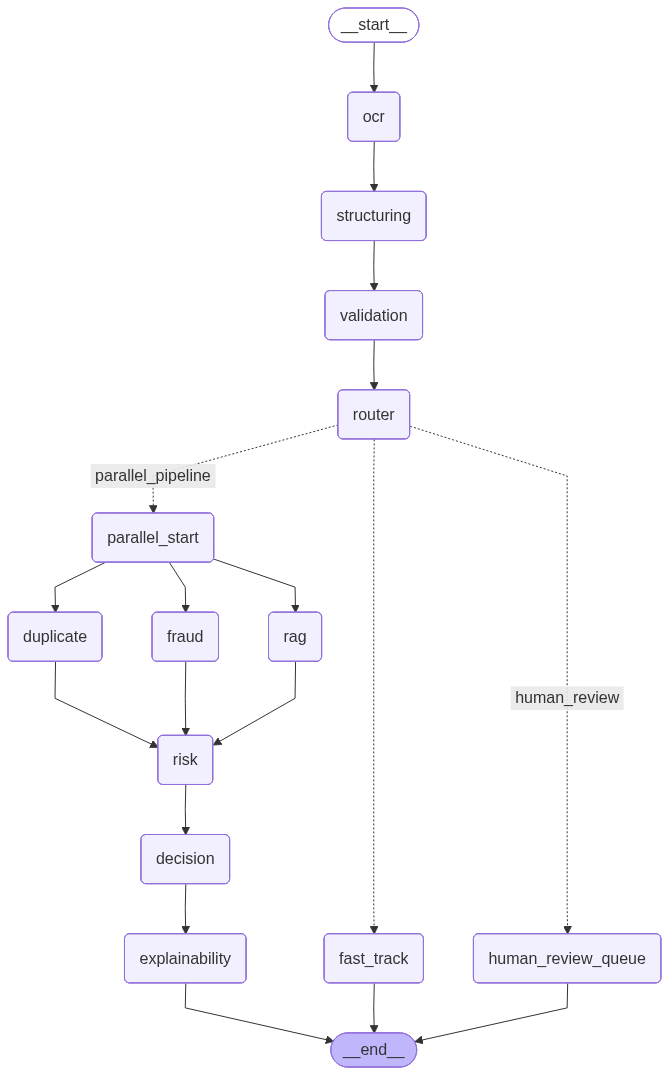

In [27]:
#Mermaid diagram
from IPython.display import display, Image

try:
    img = workflow.workflow.get_graph().draw_mermaid_png()
    display(Image(img))
except Exception as e:
    print(f"PNG render failed: {e}")
    # Fallback — print Mermaid source you can paste at mermaid.live
    print(workflow.workflow.get_graph().draw_mermaid())

In [28]:
from IPython.display import display, Markdown

def display_results(state: WorkflowState):
    cd  = state.get("claim_data", {})
    vr  = state.get("validation_result", {})
    fa  = state.get("fraud_analysis", {})
    rs  = state.get("risk_score", {})
    dup = state.get("duplicate_check", {})
    dr  = state.get("decision_result", {})
    ex  = state.get("explanation", {})
    rr  = state.get("rag_result", {})

    decision_emoji = {"APPROVED": "✅", "REJECTED": "❌", "ESCALATE": "⚠️"}.get(
        dr.get("decision", ""), "❓")

    md_text = f"""
## {decision_emoji} Claim Processing Report

### 📋 Structured Claim Data
| Field | Value |
|-------|-------|
| Claim ID | {cd.get('claim_id','—')} |
| Patient | {cd.get('patient_name','—')} |
| Hospital | {cd.get('hospital_name','—')} |
| Diagnosis | {cd.get('diagnosis','—')} |
| Treatment | {cd.get('treatment','—')} |
| Claim Amount | ₹{cd.get('claim_amount','—')} |
| Admission | {cd.get('admission_date','—')} |
| Discharge | {cd.get('discharge_date','—')} |
| Policy | {cd.get('policy_number','—')} |

### ✅ Validation
- **Valid**: {vr.get('is_valid', False)}
- **Confidence**: {vr.get('confidence_score', 0):.1%}
- **Errors**: {vr.get('errors', [])}
- **Warnings**: {vr.get('warnings', [])}
- **Missing Fields**: {vr.get('missing_fields', [])}

### 🚦 Routing
- **Route**: `{state.get('route_decision','—')}`
- **Reasoning**: {state.get('route_reasoning','—')}

### 🕵️ Fraud Analysis
- **Score**: {fa.get('fraud_score', 0):.2f} / 1.00  |  **Level**: {fa.get('risk_level','—')}
- **Indicators**: {fa.get('fraud_indicators', [])}

### 📚 Policy Coverage (RAG)
{rr.get('coverage_analysis', 'No policy documents ingested.')}

### ⚠️ Risk Score
- **Score**: {rs.get('risk_score', 0):.2f} / 1.00  |  **Severity**: {rs.get('severity','—')}
- **Factors**: {rs.get('risk_factors', [])}

### 🔁 Duplicate Check
- **Is Duplicate**: {dup.get('is_duplicate', False)}

### ⚖️ Final Decision — `{dr.get('decision','—')}` (confidence: {dr.get('confidence',0):.1%})
**Reasoning**: {dr.get('reasoning','—')}
**Recommended Action**: {dr.get('recommended_action','—')}

### 💬 Explanation
{ex.get('human_readable_explanation', ex.get('summary','—'))}

### 🏁 Audit Trail
{len(state.get('audit_trail', []))} entries recorded.
- Start: {state.get('workflow_start_time','—')}
- End:   {state.get('workflow_end_time','—')}
"""
    display(Markdown(md_text))




##Upload a Real Claim PDF

Run this cell to upload a PDF from your local machine and process it through the pipeline.


In [31]:
from google.colab import files as colab_files
import tempfile, os

print("Select a claim PDF to upload…")
uploaded = colab_files.upload()

for filename, data in uploaded.items():
    with tempfile.NamedTemporaryFile(suffix=".pdf", delete=False) as tmp:
        tmp.write(data)
        tmp_path = tmp.name

    print(f"Processing: {filename} ({len(data)/1024:.1f} KB)")
    result_pdf = workflow.run(claim_pdf_path=tmp_path)
    display_results(result_pdf)
    os.unlink(tmp_path)
    break


Select a claim PDF to upload…


Saving CLM1003_Priya.pdf to CLM1003_Priya.pdf
Processing: CLM1003_Priya.pdf (5.6 KB)


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



## ✅ Claim Processing Report

### 📋 Structured Claim Data
| Field | Value |
|-------|-------|
| Claim ID | CLM1003 |
| Patient | Priya Menon |
| Hospital | Fortis La Femme |
| Diagnosis | Normal Delivery – Term Pregnancy |
| Treatment | Normal Vaginal Delivery |
| Claim Amount | ₹62000.0 |
| Admission | 2026-03-18 |
| Discharge | 2026-03-20 |
| Policy | POL78934 |

### ✅ Validation
- **Valid**: True
- **Confidence**: 100.0%
- **Errors**: []
- **Warnings**: []
- **Missing Fields**: []

### 🚦 Routing
- **Route**: `parallel_pipeline`
- **Reasoning**: The claim has high confidence (1.00), no errors, no warnings, and all recommended fields are present, which are positive indicators. However, it does not qualify for 'fast_track' because the claim amount (62,000.0) is above the 50,000 threshold for low-risk claims, and it is an 'Inpatient' claim, not 'Dental or Outpatient'. It is not 'human_review' (high risk) as it meets none of the high-risk criteria; the claim amount is well below the 500,000 threshold for surgery/emergency claims, and there are no critical errors or mismatches. The claim amount of 62,000.0 falls within the 'moderate claim amounts (50k-500k)' category, making it a medium risk.

### 🕵️ Fraud Analysis
- **Score**: 0.00 / 1.00  |  **Level**: LOW
- **Indicators**: []

### 📚 Policy Coverage (RAG)
The claim (CLM1003) is for an Inpatient Normal Vaginal Delivery (CPT 59400) due to a Normal Delivery – Term Pregnancy (ICD-10: Z37.0) for Priya Menon, aged 33, under the Family Floater – Gold (FAM-GLD) policy tier. 

1.  **Coverage Determination**:
    *   **Claim Type**: Inpatient claims are covered under the FAM-GLD policy, as evidenced by the 'Per-Hospitalisation Limit' parameter (Rs. 750,000).
    *   **Diagnosis & Treatment**: The policy explicitly lists 'Maternity' under 'Additional Documents by Claim Type', requiring a 'Delivery certificate' and 'Birth certificate'. This confirms that maternity-related treatments, including normal delivery, are covered benefits under this policy.
    *   **Provider Specialty**: The treatment was performed by an Obstetrics & Gynaecology specialist, which is appropriate and does not impact coverage.

2.  **Exclusions & Limitations**:
    *   **Age-based exclusions**: The patient's age (33) falls within the typical adult coverage for a family floater policy. No specific age-based exclusions for maternity are mentioned in the provided clauses.
    *   **Employment status restrictions**: No restrictions based on employment status are mentioned.
    *   **Treatment-specific exclusions**: There are no explicit exclusions for normal vaginal delivery or term pregnancy in the provided policy clauses; rather, maternity is implied as a covered benefit.

3.  **Financial Coverage**:
    *   **Coverage percentage**: The claim details state a 'Co-payment %' of 0, indicating 100% coverage of the eligible amount, up to the policy limits, as no other specific coverage percentage for maternity is provided.
    *   **Policy Limits**: The claim amount of Rs. 62,000 is well within the 'Annual Policy Limit' of Rs. 2,000,000 and the 'Per-Hospitalisation Limit' of Rs. 750,000 for the FAM-GLD policy.
    *   **Co-payment requirements**: No co-payment is required from the patient (0%).

**Conclusion**: Based on the available information, the claim for Normal Delivery is fully covered under the Family Floater – Gold policy.

### ⚠️ Risk Score
- **Score**: 0.00 / 1.00  |  **Severity**: LOW
- **Factors**: []

### 🔁 Duplicate Check
- **Is Duplicate**: False

### ⚖️ Final Decision — `APPROVED` (confidence: 100.0%)
**Reasoning**: The claim (CLM1003) for Priya Menon, a 33-year-old female, is for an Inpatient Normal Vaginal Delivery (CPT 59400) due to a Normal Delivery – Term Pregnancy (ICD-10: Z37.0) provided by Fortis La Femme (Obstetrics & Gynaecology). All 23 fields have been thoroughly analyzed. The claim passed validation with 100% confidence, showing no errors, warnings, or missing information. Fraud detection and risk assessment scores are both low (0.00), indicating no suspicious activity or unusual risk factors. A duplicate check confirmed this is a unique submission. The policy (POL78934, FAM-GLD tier) explicitly covers this type of service at 100%, with no applicable exclusions and a 0% co-payment. The claim amount of $62,000.00 is well within the policy limit of $2,000,000.00. The diagnosis, treatment, and provider specialty are all perfectly aligned and medically appropriate. This is a clear, valid, and fully covered claim.
**Recommended Action**: Process the claim for full payment to the provider.

### 💬 Explanation
Dear Priya Menon,

We are thrilled to share some wonderful news regarding your recent claim, CLM1003, for your normal delivery. We understand that welcoming a new baby is a special time, and we want to make sure your focus remains on your family.

We've thoroughly reviewed all the details of your claim, and we are delighted to inform you that it has been **fully approved**. This means we will cover the entire claim amount of $62,000.00, and you will have no out-of-pocket expenses for this service.

Our decision was based on a comprehensive analysis of several key factors:

*   **Full Coverage:** Your policy, POL78934, under the FAM-GLD tier, explicitly covers normal delivery services at 100%. This is fantastic news, as it means the full cost of your treatment is covered.
*   **No Patient Responsibility:** We confirmed that there are no applicable exclusions for this type of claim, and your policy includes a 0% co-payment. This ensures you won't have any financial responsibility for this approved service.
*   **Complete and Valid Claim:** All 23 fields of your claim were meticulously reviewed and passed our validation checks with 100% confidence. There were no errors, warnings, or missing information, and we confirmed it was a unique submission.
*   **Medically Appropriate Care:** The diagnosis of 'Normal Delivery – Term Pregnancy' and the 'Normal Vaginal Delivery' treatment provided by Fortis La Femme (Obstetrics & Gynaecology) were perfectly aligned and medically appropriate, as expected.
*   **Within Policy Limits:** The claim amount of $62,000.00 is well within your policy's generous overall limit of $2,000,000.00.

**What Happens Next?**

You don't need to do anything further regarding this claim. We will now proceed with processing the payment of $62,000.00 directly to Fortis La Femme. You can expect to receive an Explanation of Benefits (EOB) in the mail or via your online portal within the next 7-10 business days, detailing this payment.

We hope this brings you peace of mind during this joyous time. If you have any questions or need further assistance, please don't hesitate to contact our member services team.

Warmly,
Your Insurance Team

### 🏁 Audit Trail
1006 entries recorded.
- Start: 2026-05-26T04:49:38.402358
- End:   2026-05-26T04:51:14.185908


In [37]:
from google.colab import files as colab_files
import tempfile, os

print("Select a claim PDF to upload…")
uploaded = colab_files.upload()

for filename, data in uploaded.items():
    with tempfile.NamedTemporaryFile(suffix=".pdf", delete=False) as tmp:
        tmp.write(data)
        tmp_path = tmp.name

    print(f"Processing: {filename} ({len(data)/1024:.1f} KB)")
    result_pdf = workflow.run(claim_pdf_path=tmp_path)
    display_results(result_pdf)
    os.unlink(tmp_path)
    break


Select a claim PDF to upload…


Saving CLM1002_Rohan.pdf to CLM1002_Rohan (1).pdf
Processing: CLM1002_Rohan (1).pdf (5.5 KB)



## ❓ Claim Processing Report

### 📋 Structured Claim Data
| Field | Value |
|-------|-------|
| Claim ID | CLM1002 |
| Patient | Rohan Verma |
| Hospital | Apollo Dental Centre Provider ID PRV1102 Provider Specialty Dental |
| Diagnosis | Dental Trauma – Fractured Incisor (Accident) |
| Treatment | Emergency Dental Extraction + Restoration |
| Claim Amount | ₹9800.0 |
| Admission | 2026-04-05 |
| Discharge | 2026-04-05 |
| Policy | POL41187 |

### ✅ Validation
- **Valid**: True
- **Confidence**: 100.0%
- **Errors**: []
- **Warnings**: []
- **Missing Fields**: []

### 🚦 Routing
- **Route**: `fast_track`
- **Reasoning**: Low-risk: Dental, amount 9800.0, complete codes

### 🕵️ Fraud Analysis
- **Score**: 0.00 / 1.00  |  **Level**: —
- **Indicators**: []

### 📚 Policy Coverage (RAG)
No policy documents ingested.

### ⚠️ Risk Score
- **Score**: 0.00 / 1.00  |  **Severity**: —
- **Factors**: []

### 🔁 Duplicate Check
- **Is Duplicate**: False

### ⚖️ Final Decision — `—` (confidence: 0.0%)
**Reasoning**: —
**Recommended Action**: —

### 💬 Explanation
—

### 🏁 Audit Trail
60 entries recorded.
- Start: 2026-05-26T06:38:35.514172
- End:   2026-05-26T06:40:55.045217


## 🔍 Step 19 — Audit Trail Inspector

In [30]:
import pandas as pd

audit = result_pdf.get("audit_trail", [])
if audit:
    df = pd.DataFrame([
        {
            "timestamp": e["timestamp"],
            "agent":     e["agent"],
            "action":    e["action"],
            "details":   str(e["details"])
        }
        for e in audit
    ])
    display(df)
else:
    print("No audit entries found.")


,timestamp,agent,action,details
0,2026-05-26T04:47:33.599500,OCRAgent,ocr_extraction,"{'method': 'llm', 'text_length': 1845, 'has_ke..."
1,2026-05-26T04:47:33.599500,OCRAgent,ocr_extraction,"{'method': 'llm', 'text_length': 1845, 'has_ke..."
2,2026-05-26T04:47:40.993128,StructuringAgent,data_structuring,"{'method': 'llm', 'fields_extracted': 23, 'tot..."
3,2026-05-26T04:47:33.599500,OCRAgent,ocr_extraction,"{'method': 'llm', 'text_length': 1845, 'has_ke..."
4,2026-05-26T04:47:33.599500,OCRAgent,ocr_extraction,"{'method': 'llm', 'text_length': 1845, 'has_ke..."
5,2026-05-26T04:47:40.993128,StructuringAgent,data_structuring,"{'method': 'llm', 'fields_extracted': 23, 'tot..."
6,2026-05-26T04:47:58.361436,ValidationAgent,validation,"{'method': 'llm', 'is_valid': False}"
7,2026-05-26T04:47:33.599500,OCRAgent,ocr_extraction,"{'method': 'llm', 'text_length': 1845, 'has_ke..."
8,2026-05-26T04:47:33.599500,OCRAgent,ocr_extraction,"{'method': 'llm', 'text_length': 1845, 'has_ke..."
9,2026-05-26T04:47:40.993128,StructuringAgent,data_structuring,"{'method': 'llm', 'fields_extracted': 23, 'tot..."


## Install Gradio

In [32]:
!pip install -q gradio

##Launch Gradio Interface

In [36]:
import gradio as gr
import json
import pandas as pd
from datetime import datetime
import threading

# Global variables to store history and pending reviews
claim_history = []
pending_reviews = []  # Claims awaiting human review
human_decisions = {}  # Store human review decisions

def process_claim(pdf_file, progress=gr.Progress()):
    """Process a healthcare claim and return results with progress tracking"""
    try:
        # Validate input
        if pdf_file is None:
            return "❌ Please upload a PDF claim", "", "", ""

        # Clear previous results immediately by returning empty strings first
        # This prevents old results from showing blurred

        # Progress tracking - lightweight updates without delays
        progress(0.0, desc="📄 Starting claim processing...")

        # Process PDF - this is where the actual workflow runs
        # The workflow itself takes time, no need for artificial delays
        progress(0.1, desc="🔍 Running OCR and analysis pipeline...")

        result = workflow.run(claim_pdf_path=pdf_file.name)

        progress(0.9, desc="📝 Formatting results...")

        # Extract data
        cd = result.get('claim_data', {})
        vr = result.get('validation_result', {})
        fa = result.get('fraud_analysis', {})
        rs = result.get('risk_score', {})
        dr = result.get('decision_result', {})
        ex = result.get('explanation', {})
        rr = result.get('rag_result', {})
        dup = result.get('duplicate_check', {})

        # Store in history
        claim_record = {
            'timestamp': datetime.now().isoformat(),
            'claim_id': cd.get('claim_id', 'N/A'),
            'decision': dr.get('decision', 'N/A'),
            'result': result,
            'human_reviewed': False,
            'human_decision': None,
            'human_notes': None
        }
        claim_history.append(claim_record)

        # Add to pending reviews if ESCALATED or requires human review
        if dr.get('decision') == 'ESCALATE' or result.get('route_decision') == 'human_review':
            pending_reviews.append(claim_record)

        progress(1.0, desc="✅ Processing complete!")

        # Format decision banner
        decision = dr.get('decision', 'UNKNOWN')
        confidence = dr.get('confidence', 0)

        if decision == 'APPROVED':
            decision_html = f"""
            <div style='background-color: #d4edda; border-left: 4px solid #28a745; padding: 20px; border-radius: 5px;'>
                <h2 style='color: #155724; margin: 0;'>✅ CLAIM APPROVED</h2>
                <p style='color: #155724; margin: 10px 0 0 0;'>Confidence: {confidence:.1%}</p>
            </div>
            """
        elif decision == 'REJECTED':
            decision_html = f"""
            <div style='background-color: #f8d7da; border-left: 4px solid #dc3545; padding: 20px; border-radius: 5px;'>
                <h2 style='color: #721c24; margin: 0;'>❌ CLAIM REJECTED</h2>
                <p style='color: #721c24; margin: 10px 0 0 0;'>Confidence: {confidence:.1%}</p>
            </div>
            """
        else:
            decision_html = f"""
            <div style='background-color: #fff3cd; border-left: 4px solid #ffc107; padding: 20px; border-radius: 5px;'>
                <h2 style='color: #856404; margin: 0;'>⚠️ CLAIM ESCALATED - HUMAN REVIEW REQUIRED</h2>
                <p style='color: #856404; margin: 10px 0 0 0;'>Confidence: {confidence:.1%} - Added to Human Review Queue</p>
            </div>
            """

        # Format comprehensive claim information
        claim_info = f"""
### 📋 Claim Information

| Field | Value |
|-------|-------|
| **Claim ID** | {cd.get('claim_id', '—')} |
| **Claim Type** | {cd.get('claim_type', '—')} |
| **Claim Date** | {cd.get('claim_date', '—')} |
| **Patient Name** | {cd.get('patient_name', '—')} |
| **Patient ID** | {cd.get('patient_id', '—')} |
| **Age** | {cd.get('age', '—')} |
| **Gender** | {cd.get('gender', '—')} |
| **Date of Birth** | {cd.get('date_of_birth', '—')} |
| **Hospital** | {cd.get('hospital_name', '—')} |
| **Provider ID** | {cd.get('provider_id', '—')} |
| **Provider Specialty** | {cd.get('provider_specialty', '—')} |
| **Diagnosis** | {cd.get('diagnosis', '—')} |
| **ICD-10 Code** | {cd.get('icd_10_code', '—')} |
| **Treatment** | {cd.get('treatment', '—')} |
| **CPT Code** | {cd.get('cpt_code', '—')} |
| **Claim Amount** | ₹{cd.get('claim_amount', 0):,.2f} |
| **Admission Date** | {cd.get('admission_date', '—')} |
| **Discharge Date** | {cd.get('discharge_date', '—')} |
| **Policy Number** | {cd.get('policy_number', '—')} |
| **Policy Tier** | {cd.get('policy_tier', '—')} |
| **Annual Policy Limit** | ₹{cd.get('annual_policy_limit', 0):,.2f} |
| **Co-payment %** | {cd.get('co_payment_percentage', '—')}% |
| **Employment Status** | {cd.get('employment_status', '—')} |

---

### ✅ Validation Results
- **Valid:** {'✅ Yes' if vr.get('is_valid', False) else '❌ No'}
- **Confidence:** {vr.get('confidence_score', 0):.1%}
- **Errors:** {', '.join(vr.get('errors', [])) or 'None'}
- **Warnings:** {', '.join(vr.get('warnings', [])) or 'None'}
- **Missing Required Fields:** {', '.join(vr.get('missing_fields', [])) or 'None'}
- **Missing Recommended Fields:** {', '.join(vr.get('missing_recommended', [])) or 'None'}
"""

        # Format comprehensive analysis
        analysis_info = f"""
### 🕵️ Fraud Analysis
- **Fraud Score:** {fa.get('fraud_score', 0):.2f} / 1.00
- **Risk Level:** {fa.get('risk_level', 'UNKNOWN')}
- **Fraud Indicators:** {', '.join(fa.get('fraud_indicators', [])) or 'None detected'}
- **Reasoning:** {fa.get('reasoning', '—')}

---

### ⚠️ Risk Assessment
- **Risk Score:** {rs.get('risk_score', 0):.2f} / 1.00
- **Severity:** {rs.get('severity', 'UNKNOWN')}
- **Confidence:** {rs.get('confidence', 0):.1%}
- **Risk Factors:** {', '.join(rs.get('risk_factors', [])) or 'None identified'}

---

### 🔁 Duplicate Check
- **Is Duplicate:** {'⚠️ Yes' if dup.get('is_duplicate', False) else '✅ No'}
- **Similar Claims Found:** {len(dup.get('similar_claims', []))}
- **Reasoning:** {dup.get('reasoning', 'No duplicates detected')}

---

### 📚 Policy Coverage Analysis
- **Covered:** {'✅ Yes' if rr.get('is_covered', False) else '❌ No'}
- **Coverage Percentage:** {rr.get('coverage_percentage', 0)}%
- **Estimated Payout:** ₹{rr.get('estimated_payout', 0):,.2f}
- **Policy Clauses:** {len(rr.get('policy_clauses', []))} relevant clauses found
- **Exclusions:** {len(rr.get('exclusions', []))} exclusions apply

**Coverage Analysis:**
{rr.get('coverage_analysis', 'No policy analysis available')}
"""

        # Format decision details with explanation
        decision_info = f"""
### ⚖️ Final Decision

**Decision:** {dr.get('decision', '—')}
**Confidence:** {dr.get('confidence', 0):.1%}
**Route:** {result.get('route_decision', '—')}

**Reasoning:**
{dr.get('reasoning', '—')}

**Recommended Action:**
{dr.get('recommended_action', '—')}

---

### 💬 Detailed Explanation

**Summary:**
{ex.get('summary', '—')}

**Key Factors:**
{chr(10).join(['- ' + factor for factor in ex.get('key_factors', [])])}

**Policy References:**
{chr(10).join(['- ' + ref for ref in ex.get('policy_references', [])])}

**Full Explanation:**
{ex.get('human_readable_explanation', '—')}

---

### 📊 Processing Metadata
- **Workflow Start:** {result.get('workflow_start_time', '—')}
- **Workflow End:** {result.get('workflow_end_time', '—')}
- **OCR Method:** {result.get('ocr_method', '—')}
- **OCR Confidence:** {result.get('ocr_confidence', 0):.1%}
- **Structuring Method:** {result.get('structuring_method', '—')}
- **Validation Method:** {result.get('validation_method', '—')}
"""

        return decision_html, claim_info, analysis_info, decision_info

    except Exception as e:
        import traceback
        error_msg = f"""
        <div style='background-color: #f8d7da; border-left: 4px solid #dc3545; padding: 20px; border-radius: 5px;'>
            <h2 style='color: #721c24; margin: 0;'>❌ Error Processing Claim</h2>
            <p style='color: #721c24; margin: 10px 0 0 0;'>{str(e)}</p>
        </div>
        """
        error_details = f"```\n{traceback.format_exc()}\n```"
        return error_msg, error_details, "", ""


def clear_results():
    """Clear all output fields when starting new processing"""
    return "", "", "", ""


def get_history():
    """Get claim processing history"""
    if not claim_history:
        return pd.DataFrame()

    history_data = []
    for item in claim_history:
        res = item['result']
        history_data.append({
            'Timestamp': item['timestamp'][:19],
            'Claim ID': item['claim_id'],
            'Patient': res.get('claim_data', {}).get('patient_name', '—'),
            'Patient ID': res.get('claim_data', {}).get('patient_id', '—'),
            'Amount': f"₹{res.get('claim_data', {}).get('claim_amount', 0):,.0f}",
            'AI Decision': item['decision'],
            'Human Reviewed': '✅' if item['human_reviewed'] else '❌',
            'Final Decision': item['human_decision'] if item['human_reviewed'] else item['decision'],
            'Fraud Score': f"{res.get('fraud_analysis', {}).get('fraud_score', 0):.2f}",
            'Risk Score': f"{res.get('risk_score', {}).get('risk_score', 0):.2f}"
        })

    return pd.DataFrame(history_data)


def get_pending_reviews():
    """Get claims pending human review"""
    if not pending_reviews:
        return pd.DataFrame(), "No claims pending review"

    review_data = []
    for idx, item in enumerate(pending_reviews):
        res = item['result']
        cd = res.get('claim_data', {})
        review_data.append({
            'Index': idx,
            'Claim ID': item['claim_id'],
            'Patient': cd.get('patient_name', '—'),
            'Amount': f"₹{cd.get('claim_amount', 0):,.0f}",
            'AI Decision': item['decision'],
            'Fraud Score': f"{res.get('fraud_analysis', {}).get('fraud_score', 0):.2f}",
            'Risk Level': res.get('fraud_analysis', {}).get('risk_level', 'UNKNOWN'),
            'Submitted': item['timestamp'][:19]
        })

    return pd.DataFrame(review_data), f"**{len(pending_reviews)} claims awaiting human review**"


def get_claim_details(claim_index):
    """Get detailed information for a specific claim"""
    try:
        claim_index = int(claim_index)
        if claim_index < 0 or claim_index >= len(pending_reviews):
            return "❌ Invalid claim index", "", "", ""

        item = pending_reviews[claim_index]
        res = item['result']
        cd = res.get('claim_data', {})
        vr = res.get('validation_result', {})
        fa = res.get('fraud_analysis', {})
        rs = res.get('risk_score', {})
        dr = res.get('decision_result', {})
        ex = res.get('explanation', {})
        rr = res.get('rag_result', {})

        # Format claim details
        claim_info = f"""
## 📋 Claim Details - {item['claim_id']}

### Patient Information
- **Name:** {cd.get('patient_name', '—')}
- **Patient ID:** {cd.get('patient_id', '—')}
- **Age:** {cd.get('age', '—')} | **Gender:** {cd.get('gender', '—')}
- **DOB:** {cd.get('date_of_birth', '—')}

### Claim Information
- **Claim Type:** {cd.get('claim_type', '—')}
- **Claim Date:** {cd.get('claim_date', '—')}
- **Claim Amount:** ₹{cd.get('claim_amount', 0):,.2f}
- **Policy Number:** {cd.get('policy_number', '—')}
- **Policy Tier:** {cd.get('policy_tier', '—')}

### Medical Details
- **Hospital:** {cd.get('hospital_name', '—')}
- **Provider ID:** {cd.get('provider_id', '—')}
- **Diagnosis:** {cd.get('diagnosis', '—')}
- **ICD-10:** {cd.get('icd_10_code', '—')}
- **Treatment:** {cd.get('treatment', '—')}
- **CPT Code:** {cd.get('cpt_code', '—')}
- **Admission:** {cd.get('admission_date', '—')} → **Discharge:** {cd.get('discharge_date', '—')}
"""

        # Format AI analysis
        ai_analysis = f"""
## 🤖 AI Analysis

### Fraud Detection
- **Score:** {fa.get('fraud_score', 0):.2f} / 1.00
- **Risk Level:** {fa.get('risk_level', 'UNKNOWN')}
- **Indicators:** {', '.join(fa.get('fraud_indicators', [])) or 'None'}
- **Reasoning:** {fa.get('reasoning', '—')}

### Risk Assessment
- **Score:** {rs.get('risk_score', 0):.2f} / 1.00
- **Severity:** {rs.get('severity', 'UNKNOWN')}
- **Factors:** {', '.join(rs.get('risk_factors', [])) or 'None'}

### Validation
- **Valid:** {'✅' if vr.get('is_valid', False) else '❌'}
- **Errors:** {', '.join(vr.get('errors', [])) or 'None'}
- **Warnings:** {', '.join(vr.get('warnings', [])) or 'None'}
"""

        # Format AI decision
        ai_decision = f"""
## ⚖️ AI Decision

**Decision:** {dr.get('decision', '—')}
**Confidence:** {dr.get('confidence', 0):.1%}

**Reasoning:**
{dr.get('reasoning', '—')}

**Recommended Action:**
{dr.get('recommended_action', '—')}

---

### Explanation
{ex.get('summary', '—')}

**Key Factors:**
{chr(10).join(['- ' + f for f in ex.get('key_factors', [])])}
"""

        return claim_info, ai_analysis, ai_decision, claim_index

    except Exception as e:
        return f"❌ Error: {str(e)}", "", "", ""


def submit_human_decision(claim_index, decision, notes):
    """Submit human review decision"""
    try:
        claim_index = int(claim_index)
        if claim_index < 0 or claim_index >= len(pending_reviews):
            return "❌ Invalid claim index"

        if not decision:
            return "❌ Please select a decision"

        # Update the claim record
        claim = pending_reviews[claim_index]
        claim['human_reviewed'] = True
        claim['human_decision'] = decision
        claim['human_notes'] = notes
        claim['review_timestamp'] = datetime.now().isoformat()

        # Update in history
        for hist_item in claim_history:
            if hist_item['claim_id'] == claim['claim_id'] and hist_item['timestamp'] == claim['timestamp']:
                hist_item['human_reviewed'] = True
                hist_item['human_decision'] = decision
                hist_item['human_notes'] = notes
                hist_item['review_timestamp'] = claim['review_timestamp']
                break

        # Remove from pending reviews
        pending_reviews.pop(claim_index)

        return f"""
        <div style='background-color: #d4edda; border-left: 4px solid #28a745; padding: 20px; border-radius: 5px;'>
            <h3 style='color: #155724; margin: 0;'>✅ Review Submitted Successfully</h3>
            <p style='color: #155724; margin: 10px 0 0 0;'>
                Claim {claim['claim_id']} has been reviewed.<br>
                <strong>Decision:</strong> {decision}<br>
                <strong>Notes:</strong> {notes or 'None'}
            </p>
        </div>
        """

    except Exception as e:
        return f"""
        <div style='background-color: #f8d7da; border-left: 4px solid #dc3545; padding: 20px; border-radius: 5px;'>
            <h3 style='color: #721c24; margin: 0;'>❌ Error Submitting Review</h3>
            <p style='color: #721c24; margin: 10px 0 0 0;'>{str(e)}</p>
        </div>
        """


# Create Gradio interface
with gr.Blocks(title="Healthcare Claim Assistant", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🏥 Healthcare Claim Review Assistant

    **AI-powered multi-agent system for automated healthcare insurance claim processing**

    Powered by Gemini AI • 10 Specialized Agents • Production-Ready
    """)

    with gr.Tabs():

        # TAB 1: Process Claim
        with gr.Tab("📝 Process Claim"):
            gr.Markdown("### Submit a Healthcare Insurance Claim (PDF Only)")

            with gr.Row():
                with gr.Column(scale=2):
                    pdf_input = gr.File(
                        label="Upload PDF Claim",
                        file_types=[".pdf"],
                        file_count="single"
                    )

                    process_btn = gr.Button("🚀 Process Claim", variant="primary", size="lg")

                with gr.Column(scale=1):
                    gr.Markdown("""
                    ### Workflow Steps

                    1. 🔍 **OCR Extraction**
                    2. 📋 **Data Structuring**
                    3. ✅ **Validation**
                    4. 🚦 **Routing**
                    5. 🕵️ **Fraud Detection**
                    6. 📚 **Policy Retrieval**
                    7. ⚠️ **Risk Assessment**
                    8. 🔁 **Duplicate Check**
                    9. ⚖️ **Decision Making**
                    10. 💬 **Explanation**
                    """)

            gr.Markdown("---")
            gr.Markdown("## 📊 Results")

            decision_output = gr.HTML(label="Decision")

            with gr.Row():
                with gr.Column():
                    claim_output = gr.Markdown(label="Claim Information")
                with gr.Column():
                    analysis_output = gr.Markdown(label="Analysis")

            decision_details = gr.Markdown(label="Decision Details & Explanation")

            # Clear outputs when file is uploaded (before processing)
            pdf_input.change(
                fn=clear_results,
                inputs=[],
                outputs=[decision_output, claim_output, analysis_output, decision_details]
            )

            # Process claim when button is clicked
            process_btn.click(
                fn=process_claim,
                inputs=[pdf_input],
                outputs=[decision_output, claim_output, analysis_output, decision_details]
            )

        # TAB 2: Human Review Queue
        with gr.Tab("👤 Human Review"):
            gr.Markdown("### Claims Requiring Human Review")

            review_status = gr.Markdown("Click 'Refresh Queue' to load pending claims")

            refresh_queue_btn = gr.Button("🔄 Refresh Queue", variant="secondary")

            pending_table = gr.Dataframe(
                headers=["Index", "Claim ID", "Patient", "Amount", "AI Decision", "Fraud Score", "Risk Level", "Submitted"],
                label="Pending Reviews"
            )

            gr.Markdown("---")
            gr.Markdown("### Review Claim Details")

            with gr.Row():
                claim_index_input = gr.Number(
                    label="Enter Claim Index (from table above)",
                    value=0,
                    precision=0
                )
                load_claim_btn = gr.Button("📄 Load Claim Details", variant="secondary")

            with gr.Row():
                with gr.Column(scale=1):
                    claim_details_output = gr.Markdown(label="Claim Details")
                with gr.Column(scale=1):
                    ai_analysis_output = gr.Markdown(label="AI Analysis")

            ai_decision_output = gr.Markdown(label="AI Decision & Explanation")

            gr.Markdown("---")
            gr.Markdown("### Submit Your Review")

            with gr.Row():
                with gr.Column():
                    review_decision = gr.Radio(
                        choices=["APPROVED", "REJECTED", "REQUEST_MORE_INFO"],
                        label="Your Decision",
                        value="APPROVED"
                    )
                with gr.Column():
                    review_notes = gr.Textbox(
                        label="Review Notes (Optional)",
                        placeholder="Enter any additional notes or justification...",
                        lines=4
                    )

            hidden_claim_index = gr.Number(visible=False, value=0)

            submit_review_btn = gr.Button("✅ Submit Review", variant="primary", size="lg")
            review_result = gr.HTML(label="Review Status")

            # Event handlers
            refresh_queue_btn.click(
                fn=get_pending_reviews,
                inputs=[],
                outputs=[pending_table, review_status]
            )

            load_claim_btn.click(
                fn=get_claim_details,
                inputs=[claim_index_input],
                outputs=[claim_details_output, ai_analysis_output, ai_decision_output, hidden_claim_index]
            )

            submit_review_btn.click(
                fn=submit_human_decision,
                inputs=[hidden_claim_index, review_decision, review_notes],
                outputs=[review_result]
            )

        # TAB 3: History
        with gr.Tab("📜 Claim History"):
            gr.Markdown("### All Processed Claims")

            history_btn = gr.Button("🔄 Refresh History", variant="secondary")
            history_output = gr.Dataframe(
                headers=["Timestamp", "Claim ID", "Patient", "Patient ID", "Amount", "AI Decision", "Human Reviewed", "Final Decision", "Fraud Score", "Risk Score"],
                label="Claim History"
            )

            history_btn.click(
                fn=get_history,
                inputs=[],
                outputs=history_output
            )

        # TAB 4: About
        with gr.Tab("ℹ️ About"):
            gr.Markdown("""
            ## 🏥 Healthcare Claim Review Assistant

            ### Overview
            This is a production-grade multi-agent AI system for automated healthcare insurance claim processing with **human-in-the-loop review**.

            ### Features
            - **10 Specialized AI Agents** - Each agent handles a specific task
            - **Gemini LLM Integration** - Powered by Google's Gemini AI
            - **LangGraph Workflow** - Conditional routing and parallel processing
            - **RAG Pipeline** - ChromaDB + embeddings for policy retrieval
            - **Human Review Queue** - Claims requiring human oversight are flagged
            - **Full Audit Trail** - Complete transparency and compliance
            - **Comprehensive Analysis** - 23-field claim extraction and validation

            ### Agents
            1. **OCR Agent** - Extracts text from PDF claims
            2. **Structuring Agent** - Converts text to structured data (23 fields)
            3. **Validation Agent** - Validates claim data comprehensively
            4. **Router Agent** - Routes to appropriate processing path
            5. **Fraud Agent** - Detects fraud indicators
            6. **RAG Agent** - Retrieves relevant policy documents
            7. **Risk Agent** - Assesses overall risk
            8. **Duplicate Agent** - Checks for duplicate claims
            9. **Decision Agent** - Makes final decision
            10. **Explainability Agent** - Generates human-readable explanations

            ### Human Review Process
            - Claims with **ESCALATE** decision are automatically added to review queue
            - Human reviewers can approve, reject, or request more information
            - All decisions are tracked with timestamps and notes
            - Full audit trail maintained for compliance

            ### Technology Stack
            - **LangChain** - LLM orchestration
            - **LangGraph** - Workflow management
            - **Google Gemini** - Large language model
            - **ChromaDB** - Vector database
            - **Gradio** - Web interface
            - **Python** - Backend logic

            ### Built With ❤️
            Created for healthcare insurance automation with human oversight
            """)

    gr.Markdown("""
    ---
    <div style='text-align: center; color: #666;'>
        <p>🏥 Healthcare Claim Review Assistant | Powered by Gemini AI & LangGraph</p>
        <p>Built with Gradio • Multi-Agent AI System</p>
    </div>
    """)

# Launch the interface
print("\n" + "="*70)
print("🎉 Launching Gradio Interface...")
print("="*70)

demo.launch(
    share=True,  # Creates a public URL automatically!
    debug=True,
    show_error=True
)

print("\n✅ Gradio interface is now live!")
print("📱 Use the public URL above to access from any device")
print("⏸️  Keep this cell running to keep the interface active")

/tmp/ipykernel_2181/4160153083.py:414: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Healthcare Claim Assistant", theme=gr.themes.Soft()) as demo:



🎉 Launching Gradio Interface...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b38f27f1fa9f885329.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b38f27f1fa9f885329.gradio.live

✅ Gradio interface is now live!
📱 Use the public URL above to access from any device
⏸️  Keep this cell running to keep the interface active
